# Trabalho Prático 2 — Extração de Conhecimento de Dados de Espectroscopia Raman
## Grupo 1

**Unidade Curricular:** Extração de Conhecimento de Dados Biológicos (ECDB 2025/2026)  
**Grupo:** Ângela Sousa pg42489 · Luís Babo pg58817 · Ruben Fernandes pg58818


---

## Pipeline de Análise

```
Dados brutos (raman_data.csv)
        |
        v
1. Carregamento e descrição dos dados
        |
        v
2. Pré-processamento (Método B — aula EC_Raman)
   +- Cropping (400-2000 cm-1)
   +- Despiking (Whitaker-Hayes, threshold=6)
   +- Suavização Savitzky-Golay (window=15, poly=2)
   +- Correção de baseline drPLS (lam=10000, eta=1.0)
   +- Normalização Min-Max por espectro
        |
        v
3. Análise exploratória e visualização
        |
        v
4. Redução de dimensionalidade (PCA, t-SNE, UMAP)
        |
        v
5. Clustering (Hierárquico, K-Means)
        |
        v
6. Aprendizagem máquina — duas representações
   +- Espectro completo -> PCA50 -> RF / SVM / KNN / LR
   +- Peak Features     -> RF / SVM / KNN / LR
        |
        v
7. Importância de variáveis + mapeamento espectral
```

**Ferramentas:** Python 3, pandas, numpy, scipy, pybaselines, scikit-learn, umap-learn, matplotlib, seaborn


## 1. Importacoes e Configuracao

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.signal import savgol_filter, find_peaks
from scipy.cluster.hierarchy import dendrogram, linkage
from pybaselines.whittaker import drpls

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    classification_report, confusion_matrix,
    adjusted_rand_score, silhouette_score
)

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print('umap-learn nao instalado.')

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
RANDOM_STATE = 42
print('Importacoes concluidas.')


Importacoes concluidas.


## 2. Carregamento dos Dados

In [2]:
RAMAN_CSV     = 'raman_data.csv'
COMPOUND_XLSX = 'compound_data.xlsx'

df_raw  = pd.read_csv(RAMAN_CSV)
df_meta = pd.read_excel(COMPOUND_XLSX)

print(f'Dimensoes totais: {df_raw.shape}')
print(f'  {df_raw.shape[0]} espectros  |  {df_raw.shape[1]-1} variaveis de Raman Shift')
print(f'Compostos no dataset: {df_raw["label"].nunique()}')
print(df_raw['label'].value_counts().to_string())


Dimensoes totais: (3510, 3277)
  3510 espectros  |  3276 variaveis de Raman Shift
Compostos no dataset: 32
label
Cyclohexane                       145
Toluene                           127
Chloroform                        122
Benzaldehyde                      121
Acetone                           120
Tert-butyl methyl ether           117
Tert-butanol                      113
Acetic acid                       113
Benzyl bromide                    112
Dichloromethane                   111
Formic acid                       110
Ethyl Acetate                     110
2 - Propanol                      109
Ethanol                           109
1,3-Dimethyl-2-imidazolidinone    109
Diethylamine                      107
2, 2 - Dimethoxy Propane          107
Propyl acetate                    107
Butyl Acetate                     106
Diethylene Glycol                 105
N,N - Dimethylformahide           105
Methyl Isobutyl Ketone            105
Dimethyl Sulfoxide                105
Isobutylamine

## 3. Filtragem para o Grupo 1

| Composto | Fórmula | Família Química | Aplicação |
|---|---|---|---|
| 1,3-Dimethyl-2-imidazolidinone (DMI) | C₅H₁₀N₂O | Heterociclo azotado | Solvente dipolar aprótico, intermediário sintético |
| 2-Propanol | C₃H₈O | Álcool | Solvente, reagente, desinfetante |
| 2,2-Dimethoxypropane (DMP) | C₅H₁₂O₂ | Éter/acetal | Agente de desidratação, intermediário |
| 4-Methyl-2-pentanone (MIBK) | C₆H₁₂O | Cetona | Solvente industrial, reagente |
| Acetic acid | CH₃COOH | Ácido carboxílico | Reagente, solvente, preservante |
| Acetone | C₃H₆O | Cetona | Solvente universal, reagente |
| Acetonitrile | C₂H₃N | Nitrilo | Solvente polar aprótico, HPLC |
| Benzaldehyde | C₇H₆O | Aldeído aromático | Reagente, aroma (amêndoa amarga) |
| Benzyl bromide | C₇H₇Br | Halogeneto benzílico | Reagente de alquilação |
| Butyl acetate | C₆H₁₂O₂ | Éster | Solvente, diluente de tintas |

Os 10 compostos do abrangem uma diversidade de famílias químicas — álcool, cetonas, éster, ácido carboxílico, nitrilo, aldeído aromático, halogeneto benzílico, éter/acetal e heterociclo azotado. Esta heterogeneidade estrutural é vantajosa para a análise: cada família apresenta grupos funcionais com frequências de vibração características e bem documentadas na literatura, pelo que se espera que os espectros Raman sejam suficientemente distintos para suportar a discriminação automática. Em particular, compostos com grupos funcionais exclusivos — como o nitrilo do Acetonitrilo (2253 cm⁻¹) ou o C-Br do Benzyl bromide (759 cm⁻¹) — devem ser trivialmente distinguíveis, enquanto pares estruturalmente mais próximos, como 2-Propanol e 2,2-DMP (ambos com ligações C-O), constituem o maior desafio para os classificadores.


In [26]:
GROUP1_COMPOUNDS = [
    '1,3-Dimethyl-2-imidazolidinone',
    '2 - Propanol',
    '2, 2 - Dimethoxy Propane',
    '4-Methyl-2-pentanone',
    'Acetic acid',
    'Acetone',
    'Acetonitrile',
    'Benzaldehyde',
    'Benzyl bromide',
    'Butyl Acetate'
]

LABEL_MAP = {
    '1,3-Dimethyl-2-imidazolidinone': '1,3-DMI',
    '2 - Propanol':                   '2-Propanol',
    '2, 2 - Dimethoxy Propane':       '2,2-DMP',
    '4-Methyl-2-pentanone':           '4M-2P (MIBK)',
    'Acetic acid':                    'Acetic acid',
    'Acetone':                        'Acetone',
    'Acetonitrile':                   'Acetonitrile',
    'Benzaldehyde':                   'Benzaldehyde',
    'Benzyl bromide':                 'Benzyl bromide',
    'Butyl Acetate':                  'Butyl acetate'
}

df_g1 = df_raw[df_raw['label'].isin(GROUP1_COMPOUNDS)].copy()
df_g1['label_clean'] = df_g1['label'].map(LABEL_MAP)

print(f'Total de espectros do Grupo 1: {len(df_g1)}')
print(df_g1['label_clean'].value_counts().to_string())


Total de espectros do Grupo 1: 1101
label_clean
Benzaldehyde      121
Acetone           120
Acetic acid       113
Benzyl bromide    112
1,3-DMI           109
2-Propanol        109
2,2-DMP           107
Butyl acetate     106
Acetonitrile      104
4M-2P (MIBK)      100


## 4. Estrutura dos Dados

Antes de qualquer processamento, é essencial caracterizar a estrutura matricial dos dados e verificar a integridade do conjunto de espectros. A célula seguinte extrai as colunas de Raman shift, constrói a matriz espectral **X** e o vector de labels **y**, e reporta as dimensões, o intervalo espectral original, a resolução e a presença de valores omissos (*NaN*). Um dataset sem valores omissos e com resolução uniforme é condição necessária para a aplicação directa do pipeline de pré-processamento sem imputação prévia.


In [4]:
shift_cols   = [c for c in df_g1.columns if c not in ('label', 'label_clean')]
raman_shifts = np.array([float(c) for c in shift_cols])
X_raw = df_g1[shift_cols].values.astype(float)
y     = df_g1['label_clean'].values

print(f'Matriz espectral X : {X_raw.shape}')
print(f'Raman Shift min    : {raman_shifts.min():.1f} cm-1')
print(f'Raman Shift max    : {raman_shifts.max():.1f} cm-1')
print(f'Resolucao espectral: {np.diff(raman_shifts).mean():.2f} cm-1')
print(f'Valores ausentes   : {np.isnan(X_raw).sum()}')


Matriz espectral X : (1101, 3276)
Raman Shift min    : 150.0 cm-1
Raman Shift max    : 3425.0 cm-1
Resolucao espectral: 1.00 cm-1
Valores ausentes   : 0


## 5. Pré-processamento


| Passo | Método | Parâmetros |
|---|---|---|
| Cropping | Intervalo 400–2000 cm⁻¹ | — |
| Despiking | Whitaker-Hayes (z-score robusto na derivada) | threshold=6 |
| Denoising | Savitzky-Golay | window=15, polyorder=2 |
| Baseline | drPLS | lam=10000, eta=1.0 |
| Normalização | Min-Max por espectro | [0, 1] |



### 5.1 Classes `RamanPreprocessor` e `PeakFeatures`


In [5]:
class RamanPreprocessor(BaseEstimator, TransformerMixin):
    """Pipeline Metodo B: cropping -> despike -> SG -> drPLS baseline -> min-max."""
    def __init__(self, axis=None, crop_range=(400, 2000),
                 despike_threshold=6.0, sg_window=15, sg_polyorder=2,
                 baseline_lam=10000, baseline_eta=1.0):
        self.axis              = axis
        self.crop_range        = crop_range
        self.despike_threshold = despike_threshold
        self.sg_window         = sg_window
        self.sg_polyorder      = sg_polyorder
        self.baseline_lam      = baseline_lam
        self.baseline_eta      = baseline_eta

    def fit(self, X, y=None):
        ax = np.asarray(self.axis) if self.axis is not None else np.arange(np.asarray(X).shape[1])
        lo, hi = self.crop_range
        self.crop_mask_ = (ax >= lo) & (ax <= hi)
        if self.crop_mask_.sum() == 0:
            self.crop_mask_ = np.ones(len(ax), dtype=bool)
        self.axis_cropped_ = ax[self.crop_mask_]
        return self

    @staticmethod
    def _despike(y, threshold=6.0):
        y = y.astype(float).copy()
        dy = np.diff(y)
        med_dy = np.median(dy)
        mad    = np.median(np.abs(dy - med_dy))
        if mad == 0:
            return y
        z = 0.6745 * np.abs(dy - med_dy) / mad
        spikes = np.where(z > threshold)[0]
        for s in spikes:
            lo = max(0, s - 3)
            hi = min(len(y) - 1, s + 3)
            neighbors = [v for i, v in enumerate(y[lo:hi+1]) if abs(i + lo - s) > 0]
            if neighbors:
                y[s] = np.median(neighbors)
        return y

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        Xc  = X[:, self.crop_mask_]
        out = np.empty_like(Xc)
        win = self.sg_window if self.sg_window % 2 == 1 else self.sg_window + 1
        for i, row in enumerate(Xc):
            row = self._despike(row, self.despike_threshold)
            row = np.clip(row, 0, None)
            row = savgol_filter(row, win, self.sg_polyorder)
            bl, _ = drpls(row, lam=self.baseline_lam, eta=self.baseline_eta)
            row = row - bl
            rmin, rmax = row.min(), row.max()
            out[i] = (row - rmin) / (rmax - rmin + 1e-10)
        return out


class PeakFeatures(BaseEstimator, TransformerMixin):
    """Extrai features de picos: altura, proeminencia aproximada e AUC."""
    def __init__(self, n_peaks=20, distance=5, window=10):
        self.n_peaks  = n_peaks
        self.distance = distance
        self.window   = window

    def fit(self, X, y=None):
        mean_spec = np.asarray(X).mean(axis=0)
        peaks, _  = find_peaks(mean_spec, distance=self.distance)
        if len(peaks) == 0:
            self.peak_idx_ = np.linspace(0, X.shape[1]-1, self.n_peaks, dtype=int)
        else:
            order = np.argsort(mean_spec[peaks])[::-1][:self.n_peaks]
            self.peak_idx_ = np.sort(peaks[order])
        return self

    def transform(self, X):
        X = np.asarray(X)
        L, w = X.shape[1], self.window
        rows = []
        for row in X:
            feats = []
            for p in self.peak_idx_:
                seg = row[max(0, p-w): min(L, p+w+1)]
                feats.extend([row[p], row[p] - seg.min(), np.trapz(seg)])
            rows.append(feats)
        return np.array(rows)

print('Classes RamanPreprocessor e PeakFeatures definidas.')


Classes RamanPreprocessor e PeakFeatures definidas.


### 5.2 Aplicação e Comparação Visual

A figura seguinte compara um espectro representativo de cada composto antes e após a aplicação completa do pipeline. Nos espectros brutos, a linha de base irregular resultante de fluorescência não-linear dificulta a comparação directa entre compostos, e a presença de *cosmic rays* introduz picos espúrios de intensidade muito elevada. Após o pipeline, todos os espectros ficam contidos no intervalo 400–2000 cm⁻¹, a linha de base é efectivamente corrigida e as intensidades normalizadas entre 0 e 1, tornando as assinaturas espectrais directamente comparáveis entre si e entre sessões de medição distintas.


Valores NaN: 0
Matriz apos pre-processamento: (1101, 1601)
Raman Shift: 400 - 2000 cm-1
Intensidade: [0.0000, 1.0000]


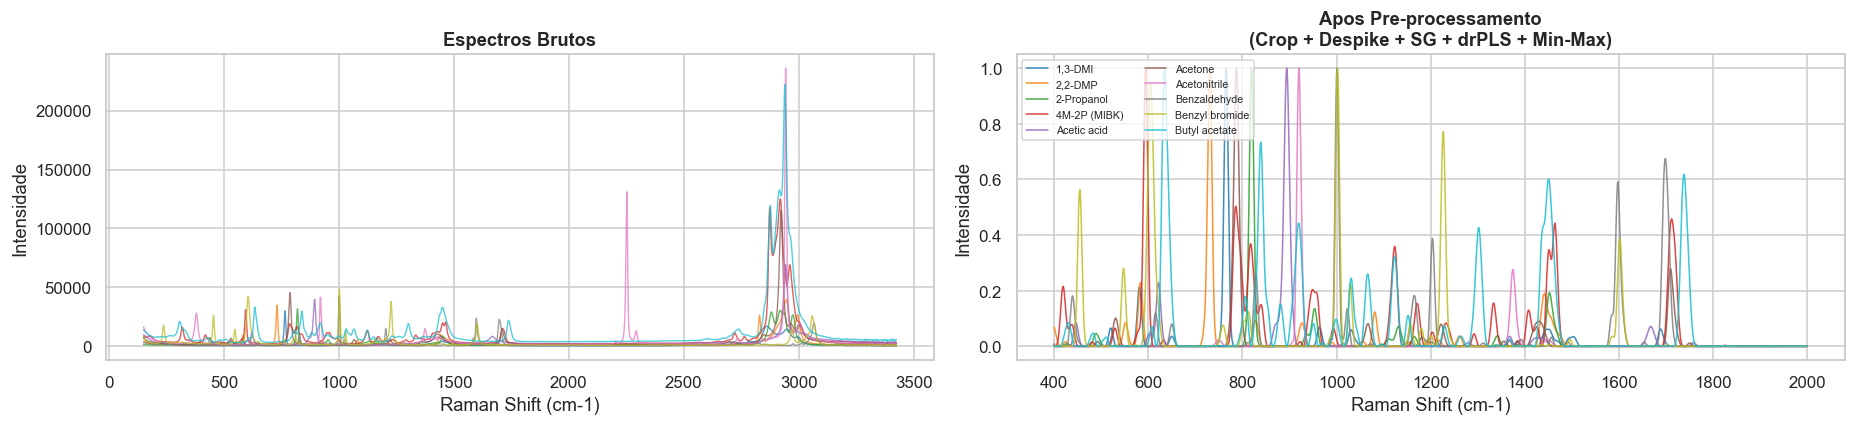

Pre-processamento concluido.


In [6]:
# NaN antes do pre-processamento
X = X_raw.copy()
nan_total = np.isnan(X).sum()
print(f'Valores NaN: {nan_total}')
if nan_total > 0:
    for i in range(X.shape[0]):
        m = np.isnan(X[i])
        if m.any():
            idx_v = np.where(~m)[0]
            X[i, m] = np.interp(np.where(m)[0], idx_v, X[i, idx_v])

pre = RamanPreprocessor(axis=raman_shifts, crop_range=(400, 2000),
                        despike_threshold=6.0, sg_window=15, sg_polyorder=2,
                        baseline_lam=10000, baseline_eta=1.0)
pre.fit(X)
X_norm = pre.transform(X)
raman_cropped = pre.axis_cropped_

print(f'Matriz apos pre-processamento: {X_norm.shape}')
print(f'Raman Shift: {raman_cropped.min():.0f} - {raman_cropped.max():.0f} cm-1')
print(f'Intensidade: [{X_norm.min():.4f}, {X_norm.max():.4f}]')

compounds = sorted(np.unique(y))
colors    = plt.cm.tab10(np.linspace(0, 1, len(compounds)))

fig, axes = plt.subplots(1, 2, figsize=(17, 4))
for compound, color in zip(compounds, colors):
    idx = np.where(y == compound)[0][0]
    axes[0].plot(raman_shifts, X[idx], lw=0.9, color=color, alpha=0.75, label=compound)
    axes[1].plot(raman_cropped, X_norm[idx], lw=1.0, color=color, alpha=0.85, label=compound)
axes[0].set_title('Espectros Brutos', fontweight='bold')
axes[1].set_title('Apos Pre-processamento\n(Crop + Despike + SG + drPLS + Min-Max)', fontweight='bold')
for ax in axes:
    ax.set_xlabel('Raman Shift (cm-1)'); ax.set_ylabel('Intensidade')
axes[1].legend(fontsize=7, loc='upper left', ncol=2)
plt.tight_layout(); plt.show()
print('Pre-processamento concluido.')


### 5.3 Efeito do Pipeline por Composto

Para verificar que o pipeline é eficaz e consistente em toda a amostragem, apresenta-se abaixo a comparação espectro bruto vs. pré-processado para cada um dos 10 compostos individualmente. Em todos os casos, o espectro bruto (cinzento, semi-transparente) apresenta uma linha de base irregular que ofusca os picos de menor intensidade, ao passo que o espectro pré-processado (colorido) revela uma estrutura de picos mais nítida e reprodutível. O efeito do despiking é particularmente visível em compostos onde os *cosmic rays* coincidem com regiões de baixa intensidade espectral.


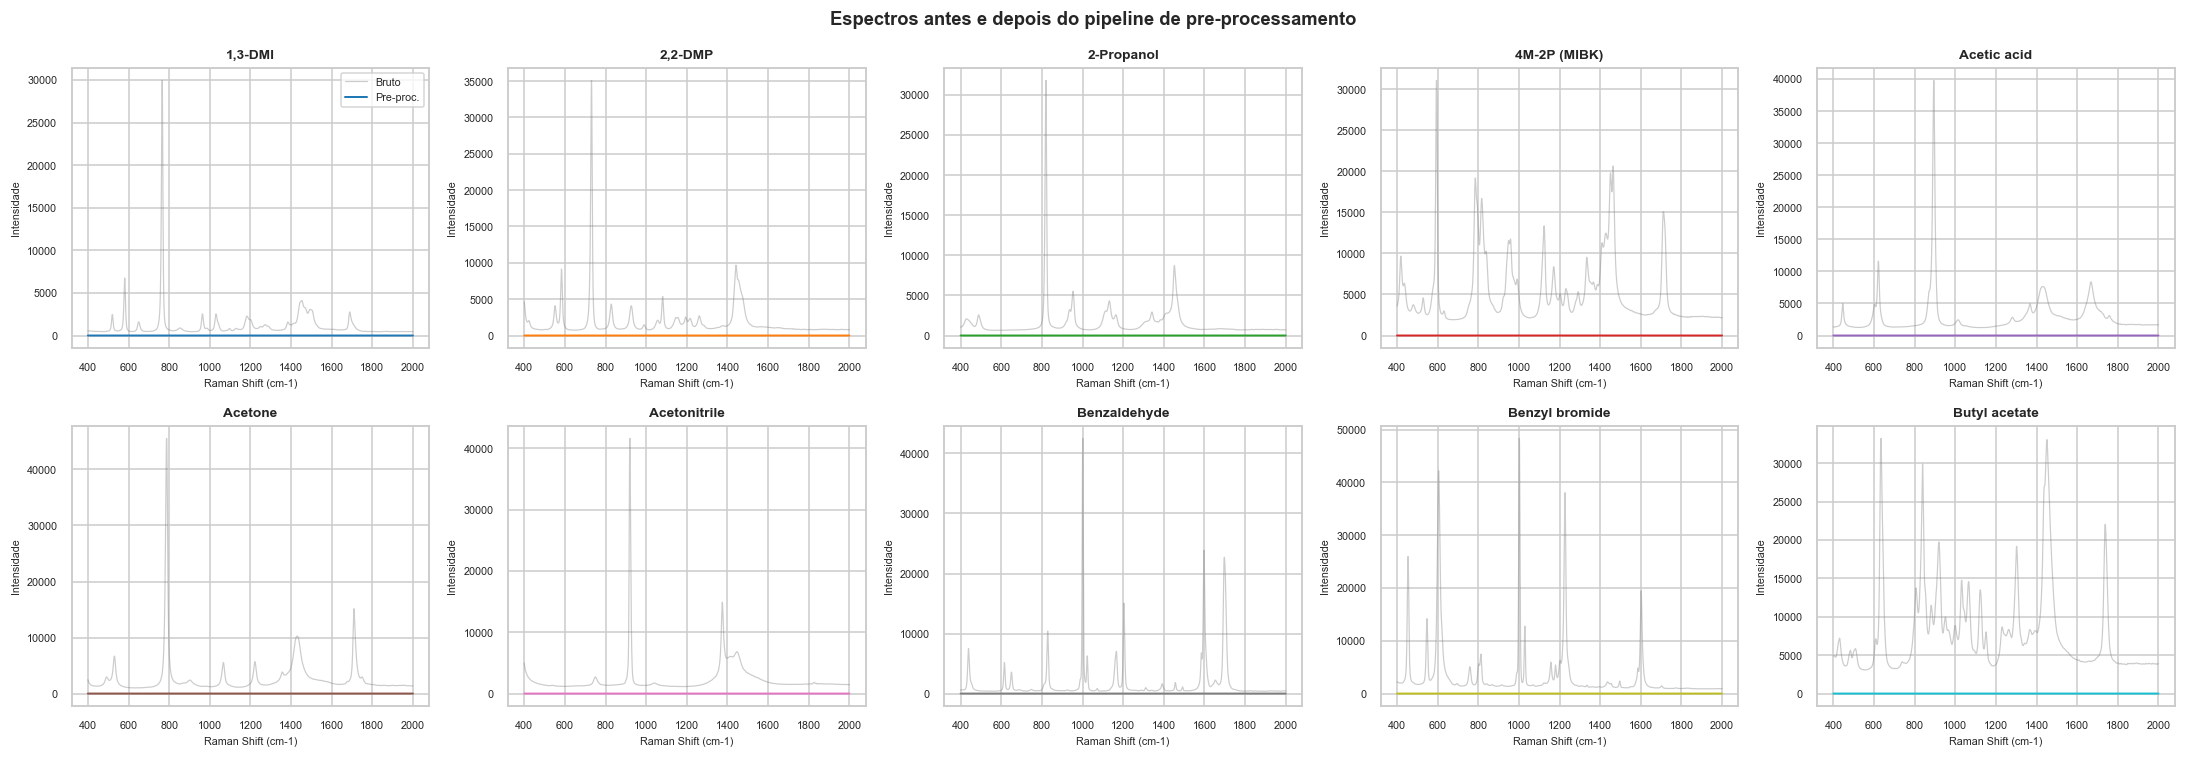

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()
for i, (compound, color) in enumerate(zip(compounds, colors)):
    idx = np.where(y == compound)[0][0]
    axes[i].plot(raman_cropped, X[idx, pre.crop_mask_], alpha=0.4, lw=0.8, color='grey', label='Bruto')
    axes[i].plot(raman_cropped, X_norm[idx], lw=1.3, color=color, label='Pre-proc.')
    axes[i].set_title(compound, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Raman Shift (cm-1)', fontsize=7)
    axes[i].set_ylabel('Intensidade', fontsize=7)
    axes[i].tick_params(labelsize=7)
    if i == 0: axes[i].legend(fontsize=7)
plt.suptitle('Espectros antes e depois do pipeline de pre-processamento', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


## 6. Sumarização e Estatística Descritiva

Após o pré-processamento, caracteriza-se quantitativamente o dataset através de estatísticas descritivas por composto e da matriz de correlação de Pearson entre espectros médios.

A tabela seguinte reporta, para cada composto: número de espectros disponíveis (*N amostras*), intensidade média global do espectro normalizado, desvio-padrão médio (medida de variabilidade intraclasse), variância espectral média e posição do pico de maior intensidade (*Raman shift* em cm⁻¹).

O dataset é aproximadamente balanceado (entre 100 e 121 espectros por classe), o que é favorável ao treino de classificadores sem necessidade de técnicas de re-amostragem. A posição do pico máximo varia substancialmente entre compostos — de 594 cm⁻¹ (4M-2P/MIBK) a 1002 cm⁻¹ (Benzyl bromide) — antecipando a elevada separabilidade espectral. A variância espectral mais elevada pertence ao Acetonitrilo, reflexo da sua banda CN muito intensa e estreita a ~920 cm⁻¹.

De seguida, A matriz de correlação de Pearson calculada sobre os espectros médios de cada composto revela que todos os pares apresentam correlações muito próximas de zero, com a excepção dos pares 4M-2P (MIBK)/Acetone (r = 0,42) e Benzaldehyde/Benzyl bromide (r = 0,37). Estes valores moderados são quimicamente esperados: a cetona 4M-2P e a acetona partilham o grupo carbonilo C=O com ressonância a ~1709 cm⁻¹, enquanto benzaldehyde e benzyl bromide partilham o anel aromático com modos de respiração a ~1001 cm⁻¹. A baixa correlação geral confirma que os 10 compostos possuem assinaturas Raman suficientemente distintas para suportar a sua discriminação por métodos de aprendizagem automática.



=== Estatistica Descritiva por Composto ===


,N amostras,Intensidade media,Std medio,Variancia espectral,Shift pico max (cm-1)
Composto,,,,,
"1,3-DMI",109,0.0138,0.0010,0.000003,765
"2,2-DMP",107,0.0177,0.0015,0.000008,731
2-Propanol,109,0.0138,0.0016,0.000006,819
4M-2P (MIBK),100,0.0477,0.0049,0.000092,594
Acetic acid,113,0.0157,0.0021,0.000009,894
Acetone,120,0.0169,0.0022,0.000016,787
Acetonitrile,104,0.0131,0.0083,0.000109,920
Benzaldehyde,121,0.0301,0.0009,0.000003,1001
Benzyl bromide,112,0.0388,0.0013,0.000019,1002


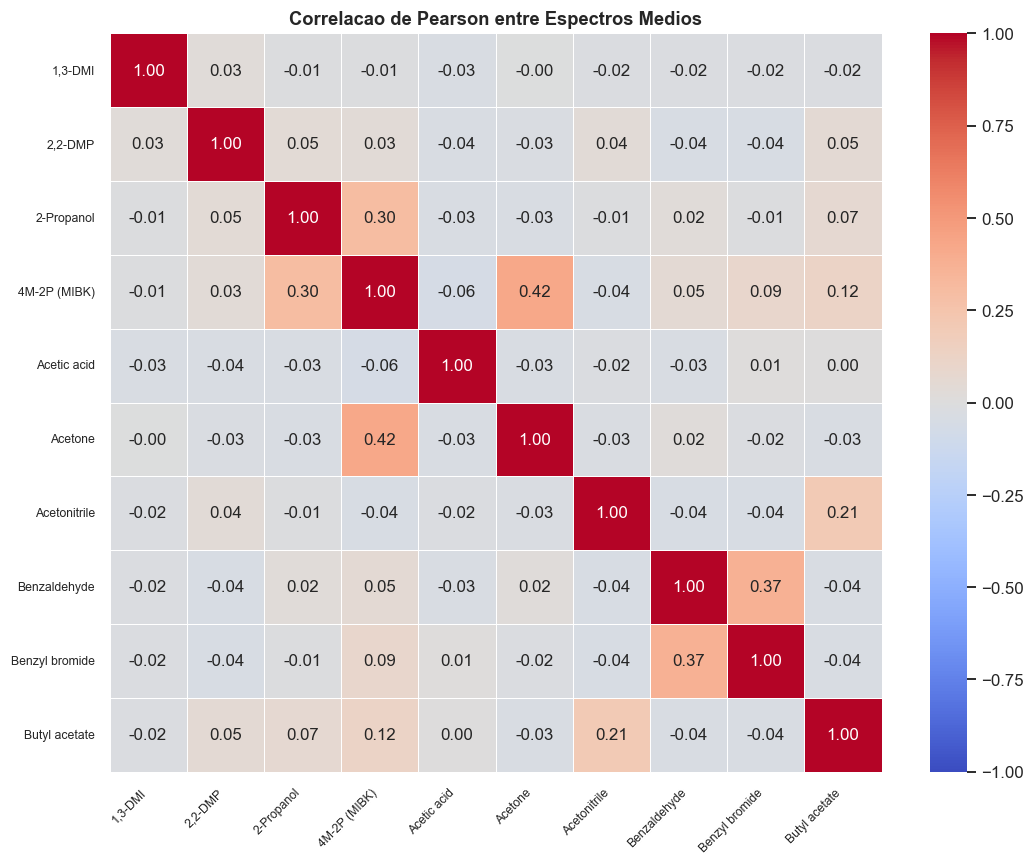

In [8]:
summary_rows = []
for compound in compounds:
    mask = y == compound
    spectra = X_norm[mask]
    peak_shift = raman_cropped[spectra.mean(axis=0).argmax()]
    summary_rows.append({
        'Composto':              compound,
        'N amostras':            int(mask.sum()),
        'Intensidade media':     round(float(spectra.mean()), 4),
        'Std medio':             round(float(spectra.std(axis=0).mean()), 4),
        'Variancia espectral':   round(float(spectra.var(axis=0).mean()), 6),
        'Shift pico max (cm-1)': f'{peak_shift:.0f}'
    })

df_summary = pd.DataFrame(summary_rows).set_index('Composto')
print('=== Estatistica Descritiva por Composto ===')
display(df_summary)

mean_spectra_arr = np.array([X_norm[y == c].mean(axis=0) for c in compounds])
corr_df = pd.DataFrame(np.corrcoef(mean_spectra_arr), index=compounds, columns=compounds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.4, ax=ax)
ax.set_title('Correlacao de Pearson entre Espectros Medios', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8); plt.yticks(fontsize=8)
plt.tight_layout(); plt.show()


## 7. Exploração Gráfica

### 7.1 Espectros Médios por Composto (média ± 1 desvio-padrão)

Os espectros médios normalizados de cada composto, acompanhados da banda de ±1 desvio-padrão, permitem caracterizar simultaneamente a assinatura espectral típica de cada classe e a sua reprodutibilidade intraclasse. Uma banda de incerteza estreita indica que o pré-processamento suprimiu eficazmente a variabilidade instrumental e que as réplicas de cada composto são altamente consistentes entre si.

Destacam-se as seguintes assinaturas: o **1,3-DMI** apresenta um pico dominante e muito estreito a ~765 cm⁻¹; o **Acetonitrilo** distingue-se pela banda CN a ~920 cm⁻¹ e pelo ombro exclusivo a ~2253 cm⁻¹; o **Benzaldehyde** e o **Benzyl bromide** partilham picos aromáticos mas diferem na região 700–800 cm⁻¹ (banda C-Br do Benzyl bromide a ~759 cm⁻¹); o **4M-2P (MIBK)** apresenta o espectro mais rico em picos, reflectindo a sua maior complexidade estrutural com vários grupos funcionais activos no Raman.


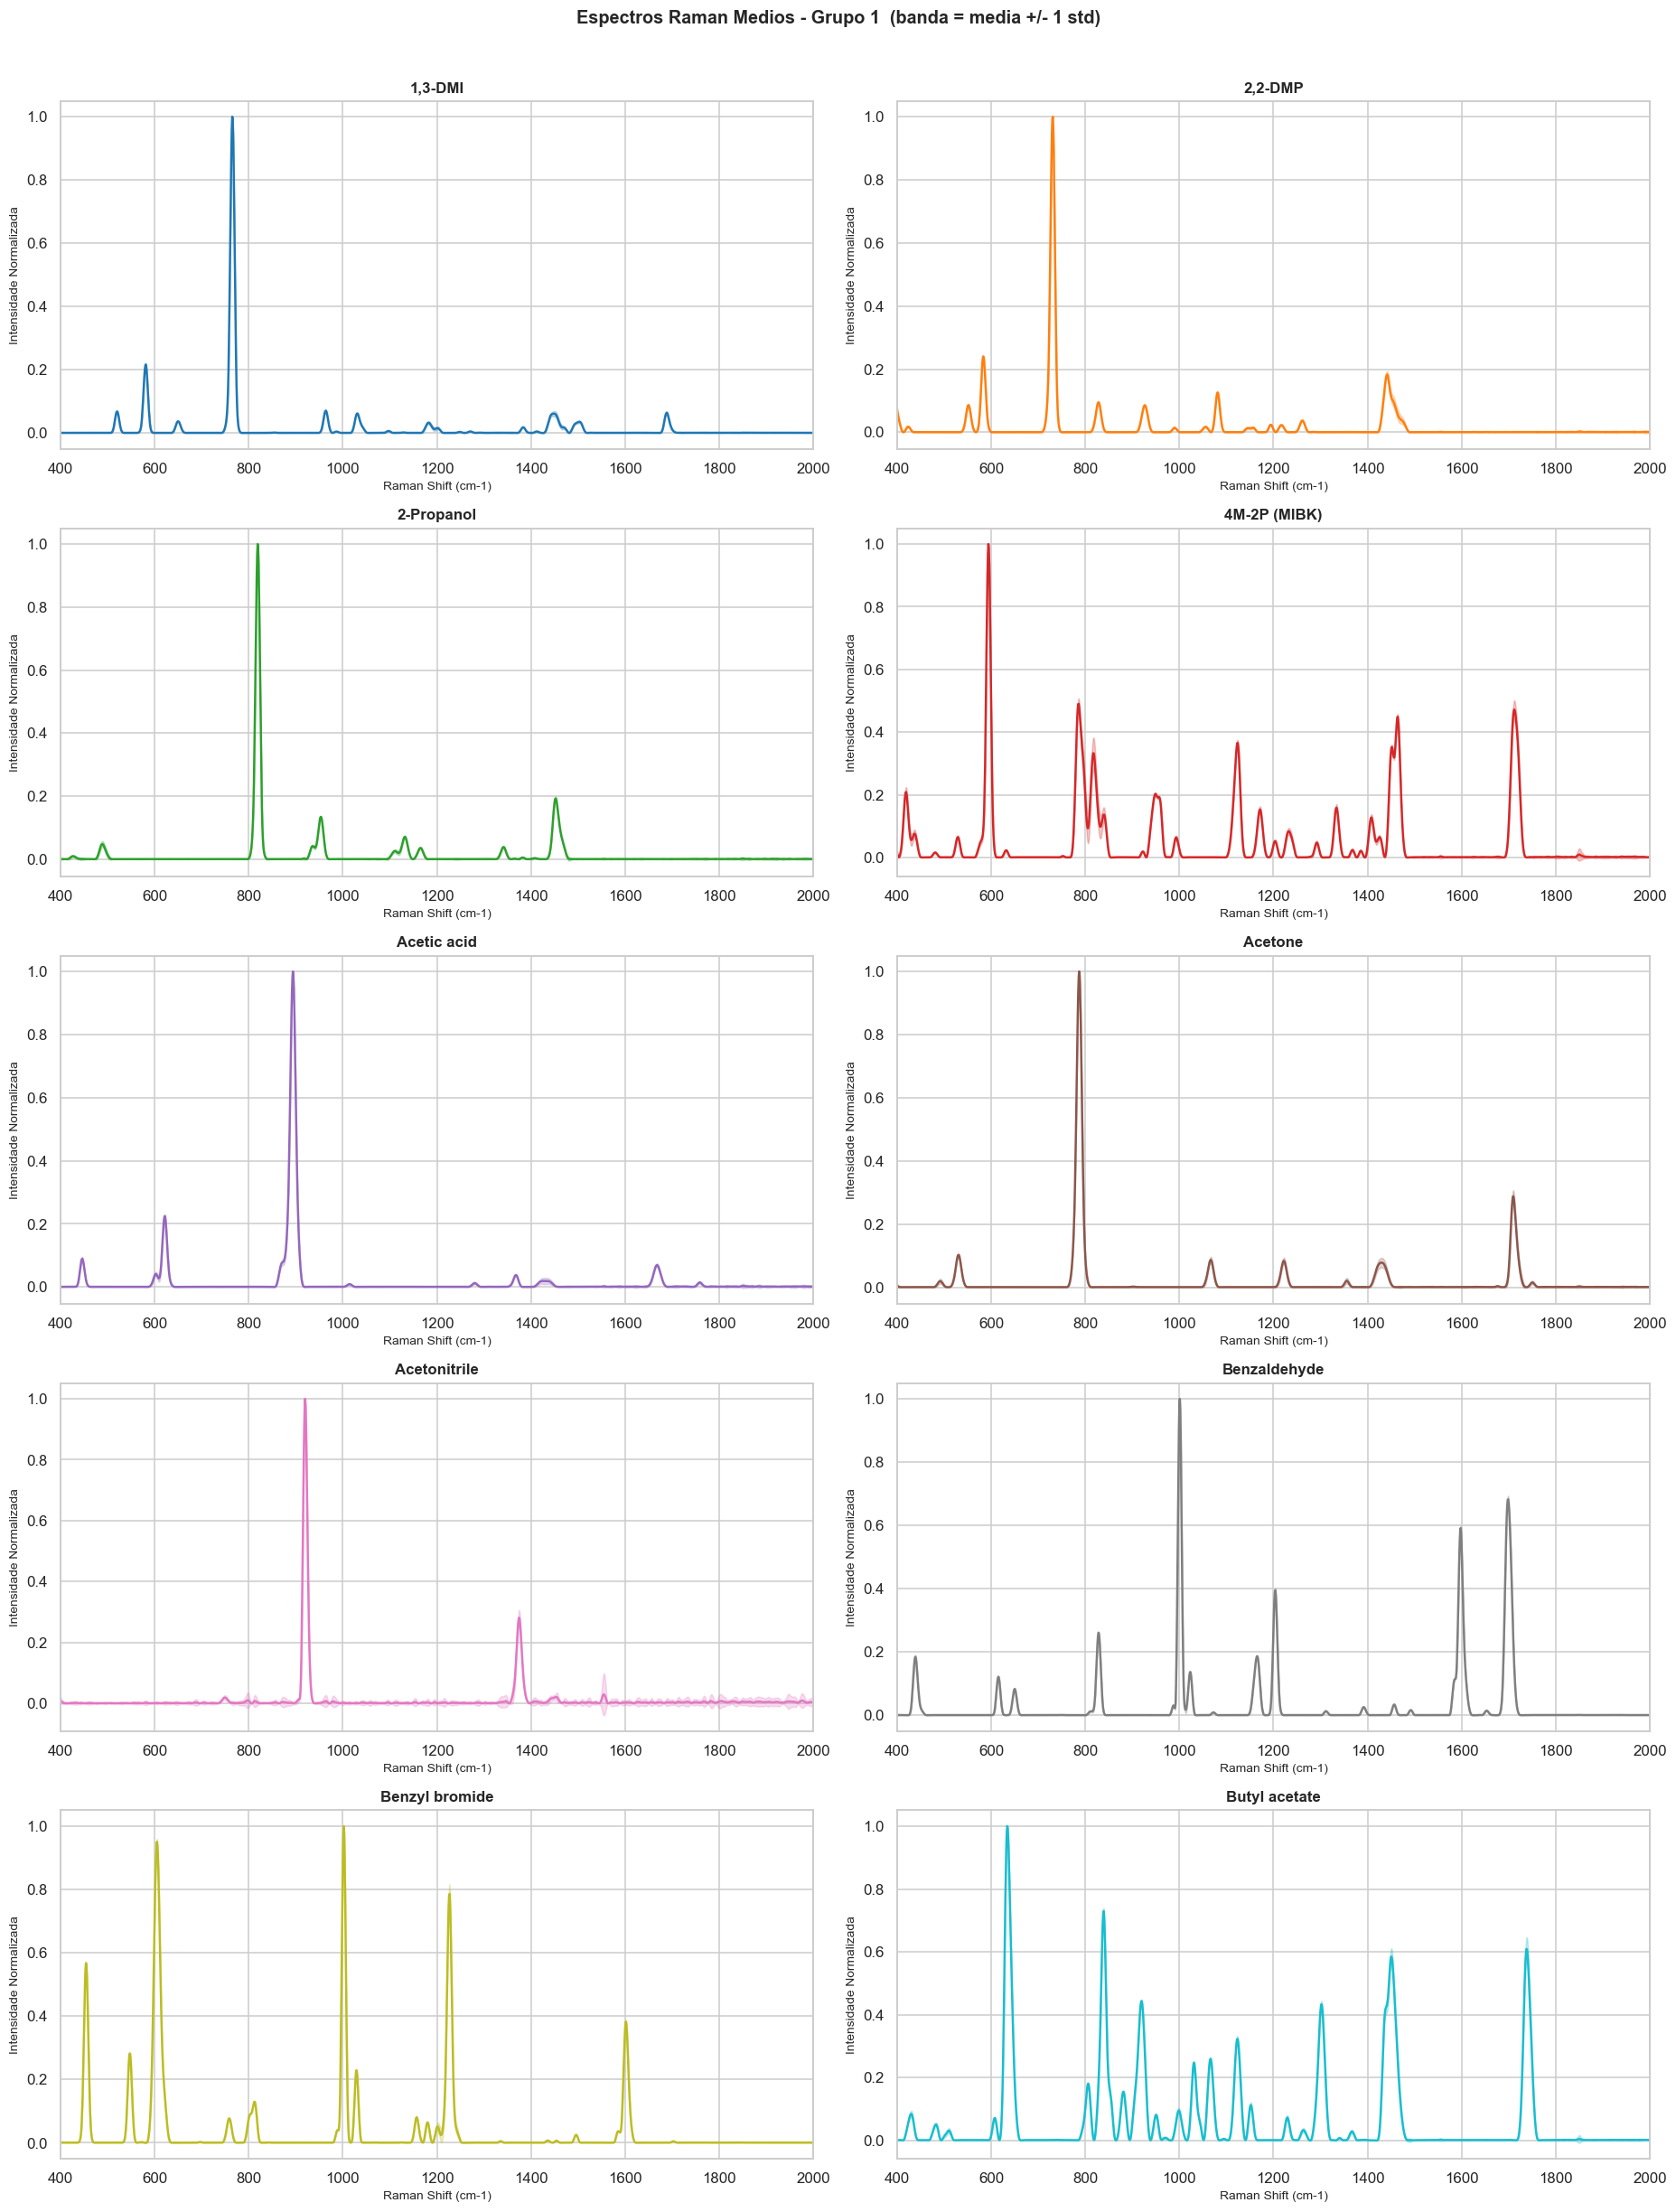

In [9]:
fig, axes = plt.subplots(5, 2, figsize=(17, 22))
axes = axes.flatten()
for i, (compound, color) in enumerate(zip(compounds, colors)):
    mask = y == compound
    spectra = X_norm[mask]
    mean_s  = spectra.mean(axis=0)
    std_s   = spectra.std(axis=0)
    axes[i].fill_between(raman_cropped, mean_s - std_s, mean_s + std_s, alpha=0.25, color=color)
    axes[i].plot(raman_cropped, mean_s, color=color, lw=1.6)
    axes[i].set_title(compound, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Raman Shift (cm-1)', fontsize=9)
    axes[i].set_ylabel('Intensidade Normalizada', fontsize=9)
    axes[i].set_xlim(raman_cropped.min(), raman_cropped.max())
plt.suptitle('Espectros Raman Medios - Grupo 1  (banda = media +/- 1 std)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


## 8. Comparação Visual e Bandas Relevantes

A sobreposição dos espectros médios dos 10 compostos numa única figura, com destaque para as principais regiões espectrais, permite identificar visualmente as bandas com maior poder discriminativo. As regiões sombreadas correspondem a zonas de particular interesse analítico:

- **400–650 cm⁻¹ (Deformação/C-X):** modos de deformação e vibrações C-halogeneto; relevante para o Benzyl bromide.
- **700–900 cm⁻¹ (C-C/C-O):** elongamentos de esqueleto carbónico e C-O; região mais densa em picos e com maior poder discriminativo global.
- **900–1250 cm⁻¹ (C-C/C-O/C-N):** elongamentos C-O de éteres e ésteres, C-N de aminas e heterociclos.
- **1400–1800 cm⁻¹ (C=O/C=C):** elongamentos de carbonilo (cetonas, ácidos, aldéidos, ésteres) e C=C aromático; separa o grupo das cetonas (Acetone, MIBK) dos compostos aromáticos (Benzaldehyde).
- **1900–2100 cm⁻¹ (CN triplo):** banda exclusiva do Acetonitrilo; constitui a banda de identificação mais fiável de todo o dataset.

Os gráficos de detalhe por região (zoom) confirmam estas observações com maior resolução espectral e identificam as bandas mais relevantes por composto dentro de cada zona.


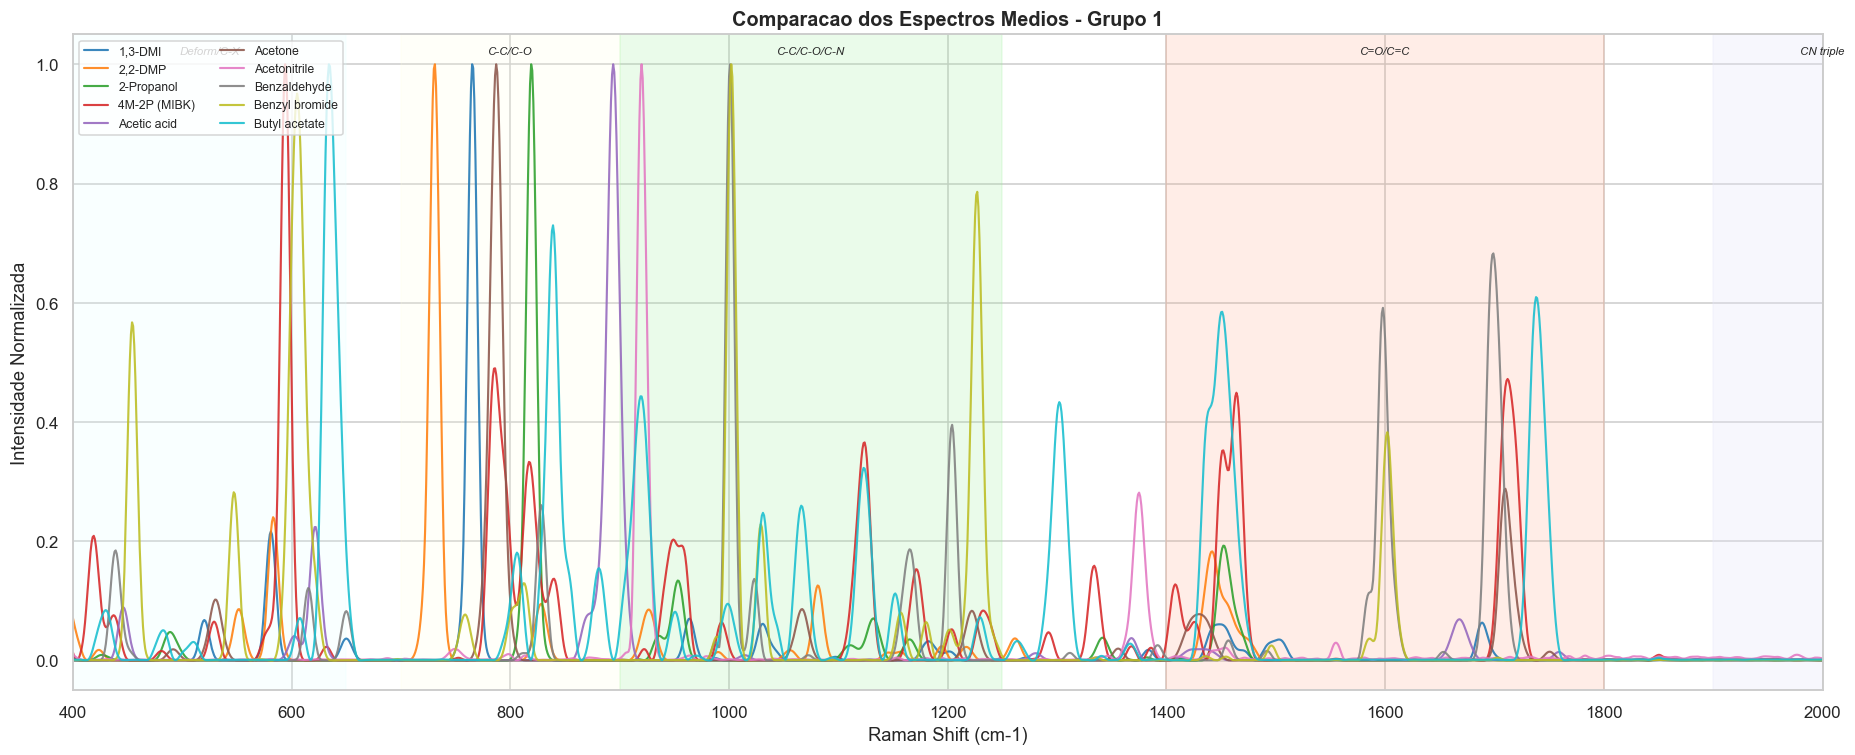

In [10]:
fig, ax = plt.subplots(figsize=(17, 7))
for compound, color in zip(compounds, colors):
    mean_s = X_norm[y == compound].mean(axis=0)
    ax.plot(raman_cropped, mean_s, label=compound, color=color, lw=1.4, alpha=0.88)

regions = [
    (400,  650,  'Deform/C-X',   'lightcyan',  0.18),
    (700,  900,  'C-C/C-O',      'lightyellow', 0.18),
    (900,  1250, 'C-C/C-O/C-N',  'lightgreen',  0.18),
    (1400, 1800, 'C=O/C=C',      'lightsalmon', 0.18),
    (1900, 2100, 'CN triple',    'lavender',    0.30),
]
for r_min, r_max, label, fc, alpha in regions:
    ax.axvspan(r_min, r_max, alpha=alpha, color=fc)
    ax.text((r_min+r_max)/2, 0.97, label, ha='center', fontsize=7.5,
            transform=ax.get_xaxis_transform(), style='italic')
ax.set_xlabel('Raman Shift (cm-1)', fontsize=12)
ax.set_ylabel('Intensidade Normalizada', fontsize=12)
ax.set_title('Comparacao dos Espectros Medios - Grupo 1', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, ncol=2, loc='upper left')
ax.set_xlim(raman_cropped.min(), raman_cropped.max())
plt.tight_layout(); plt.show()


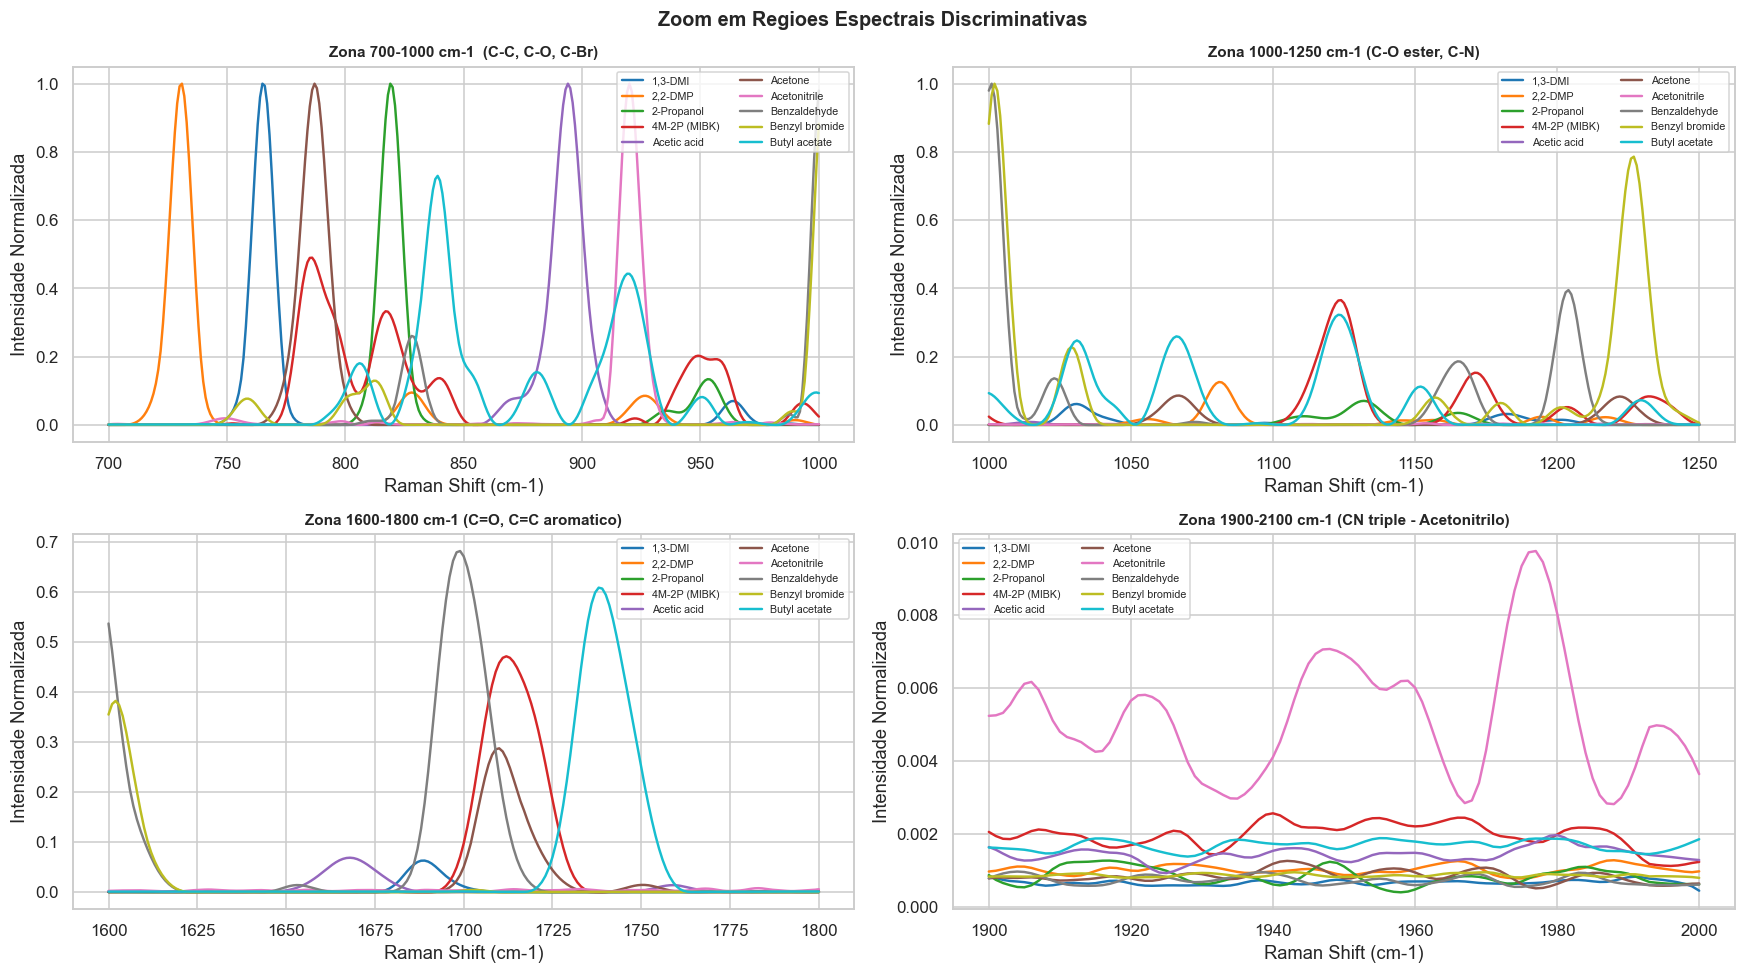

Bandas Raman mais relevantes para o Grupo 1:
  - Acetonitrilo : CN triple em ~2253 cm-1 (banda exclusiva)
  - Benzaldehyde / Benzyl bromide : anel aromatico em ~1001 cm-1
  - Benzyl bromide : C-Br stretch em ~759 cm-1
  - Acetone / 4M-2P (MIBK) : C=O cetona em ~1709 cm-1
  - Butyl acetate : C=O ester em ~1738 cm-1
  - Acetic acid : C=O acido + C-O em ~894 / 1429 cm-1
  - 1,3-DMI : C=O lactama em ~1669 cm-1


In [11]:
zoom_regions = [
    (700,  1000, 'Zona 700-1000 cm-1  (C-C, C-O, C-Br)'),
    (1000, 1250, 'Zona 1000-1250 cm-1 (C-O ester, C-N)'),
    (1600, 1800, 'Zona 1600-1800 cm-1 (C=O, C=C aromatico)'),
    (1900, 2100, 'Zona 1900-2100 cm-1 (CN triple - Acetonitrilo)'),
]
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()
for ax, (r_min, r_max, title) in zip(axes, zoom_regions):
    m = (raman_cropped >= r_min) & (raman_cropped <= r_max)
    for compound, color in zip(compounds, colors):
        mean_s = X_norm[y == compound][:, m].mean(axis=0)
        ax.plot(raman_cropped[m], mean_s, label=compound, color=color, lw=1.6)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Raman Shift (cm-1)'); ax.set_ylabel('Intensidade Normalizada')
    ax.legend(fontsize=7, ncol=2)
plt.suptitle('Zoom em Regioes Espectrais Discriminativas', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('Bandas Raman mais relevantes para o Grupo 1:')
print('  - Acetonitrilo : CN triple em ~2253 cm-1 (banda exclusiva)')
print('  - Benzaldehyde / Benzyl bromide : anel aromatico em ~1001 cm-1')
print('  - Benzyl bromide : C-Br stretch em ~759 cm-1')
print('  - Acetone / 4M-2P (MIBK) : C=O cetona em ~1709 cm-1')
print('  - Butyl acetate : C=O ester em ~1738 cm-1')
print('  - Acetic acid : C=O acido + C-O em ~894 / 1429 cm-1')
print('  - 1,3-DMI : C=O lactama em ~1669 cm-1')


## 9. Análise Multivariada Não Supervisionada

### 9.1 PCA

#### PCA — Variância Explicada

A análise de componentes principais efectuada sobre os espectros pré-processados (1601 variáveis) revela que os três primeiros componentes principais explicam, respectivamente, 18,8%, 13,9% e 12,0% da variância total. Para reter 95% da variância são necessários 21 PCs e para reter 99% da variância são necessarios 56 PCs. É possível ver no gráfico de scree a rápida queda da variância individual após os primeiros componentes o que indica que a maior parte da informação discriminativa está concentrada num subconjunto reduzido de dimensões. A representação PCA50 (50 componentes principais), que retém virtualmente 100% da variância, foi adotada como entrada para os modelos de machine learning, permitindo reduzir a dimensionalidade sem perda de informação relevante.



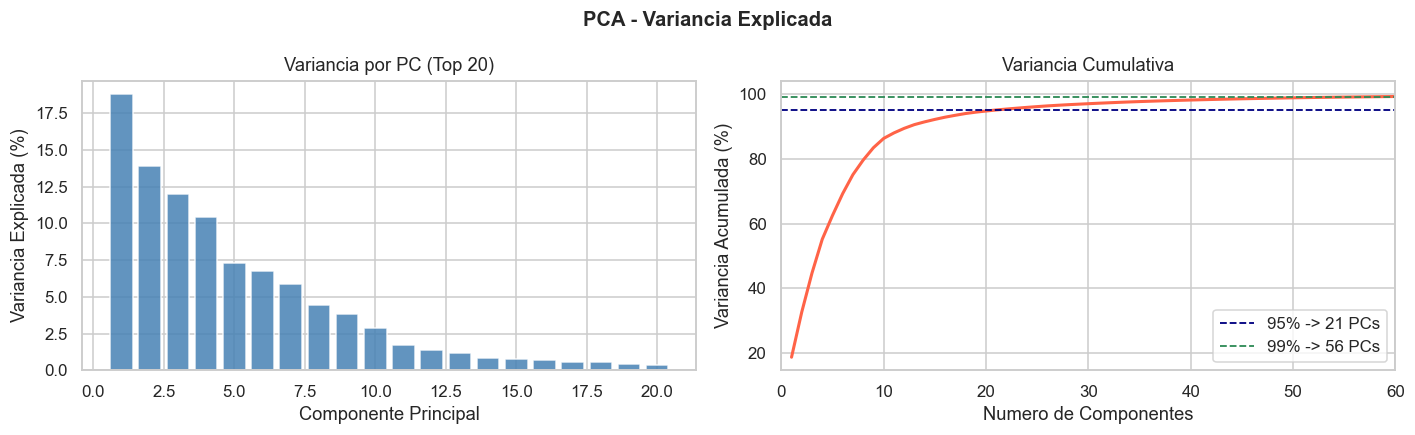

PCs para 95%: 21  |  PCs para 99%: 56
PC1: 18.8%  |  PC2: 13.9%  |  PC3: 12.0%


In [12]:
scaler   = StandardScaler()
X_sc     = scaler.fit_transform(X_norm)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_sc)
expl  = pca_full.explained_variance_ratio_
cumul = np.cumsum(expl)
n95   = int(np.argmax(cumul >= 0.95)) + 1
n99   = int(np.argmax(cumul >= 0.99)) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, 21), expl[:20]*100, color='steelblue', alpha=0.85)
axes[0].set_xlabel('Componente Principal'); axes[0].set_ylabel('Variancia Explicada (%)')
axes[0].set_title('Variancia por PC (Top 20)')
axes[1].plot(range(1, len(cumul)+1), cumul*100, color='tomato', lw=2)
axes[1].axhline(95, color='navy', ls='--', lw=1.2, label=f'95% -> {n95} PCs')
axes[1].axhline(99, color='seagreen', ls='--', lw=1.2, label=f'99% -> {n99} PCs')
axes[1].set_xlabel('Numero de Componentes'); axes[1].set_ylabel('Variancia Acumulada (%)')
axes[1].set_title('Variancia Cumulativa'); axes[1].legend(); axes[1].set_xlim(0, 60)
plt.suptitle('PCA - Variancia Explicada', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'PCs para 95%: {n95}  |  PCs para 99%: {n99}')
print(f'PC1: {expl[0]*100:.1f}%  |  PC2: {expl[1]*100:.1f}%  |  PC3: {expl[2]*100:.1f}%')


##### Loadings do PCA

Os loadings dos dois primeiros componentes principais mostram que PC1 (18,8% de variância) captura contribuições distribuídas ao longo de todo o espectro. O PC2 (13,9%) evidencia um padrão diferente, com pesos mais elevados nas regiões 500–700 cm⁻¹ e 1600–2000 cm⁻¹. A mudaça de sinais positivos e negativos reflete o carácter diferencial dos loadings, onde cada componente codifica a direção de maior variação espectral entre compostos, e não bandas isoladas.

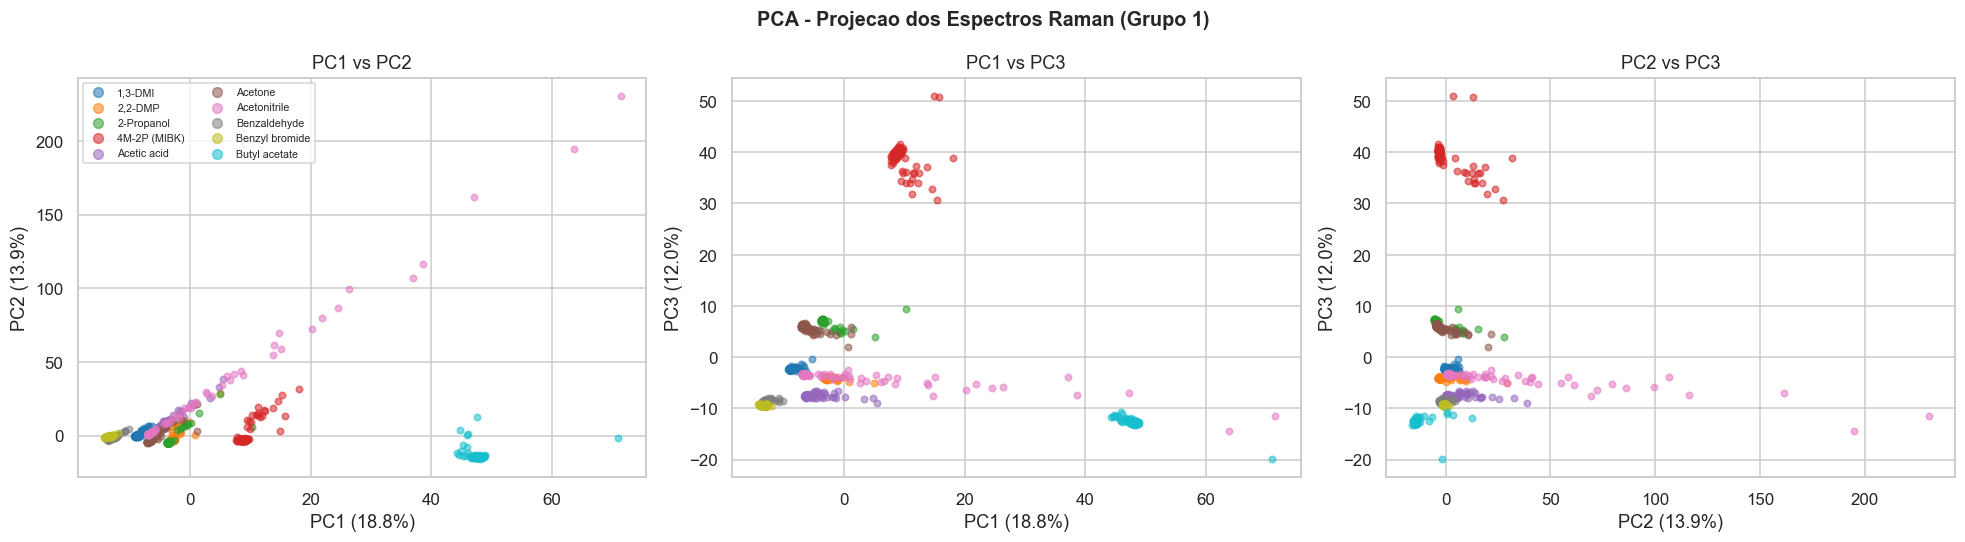

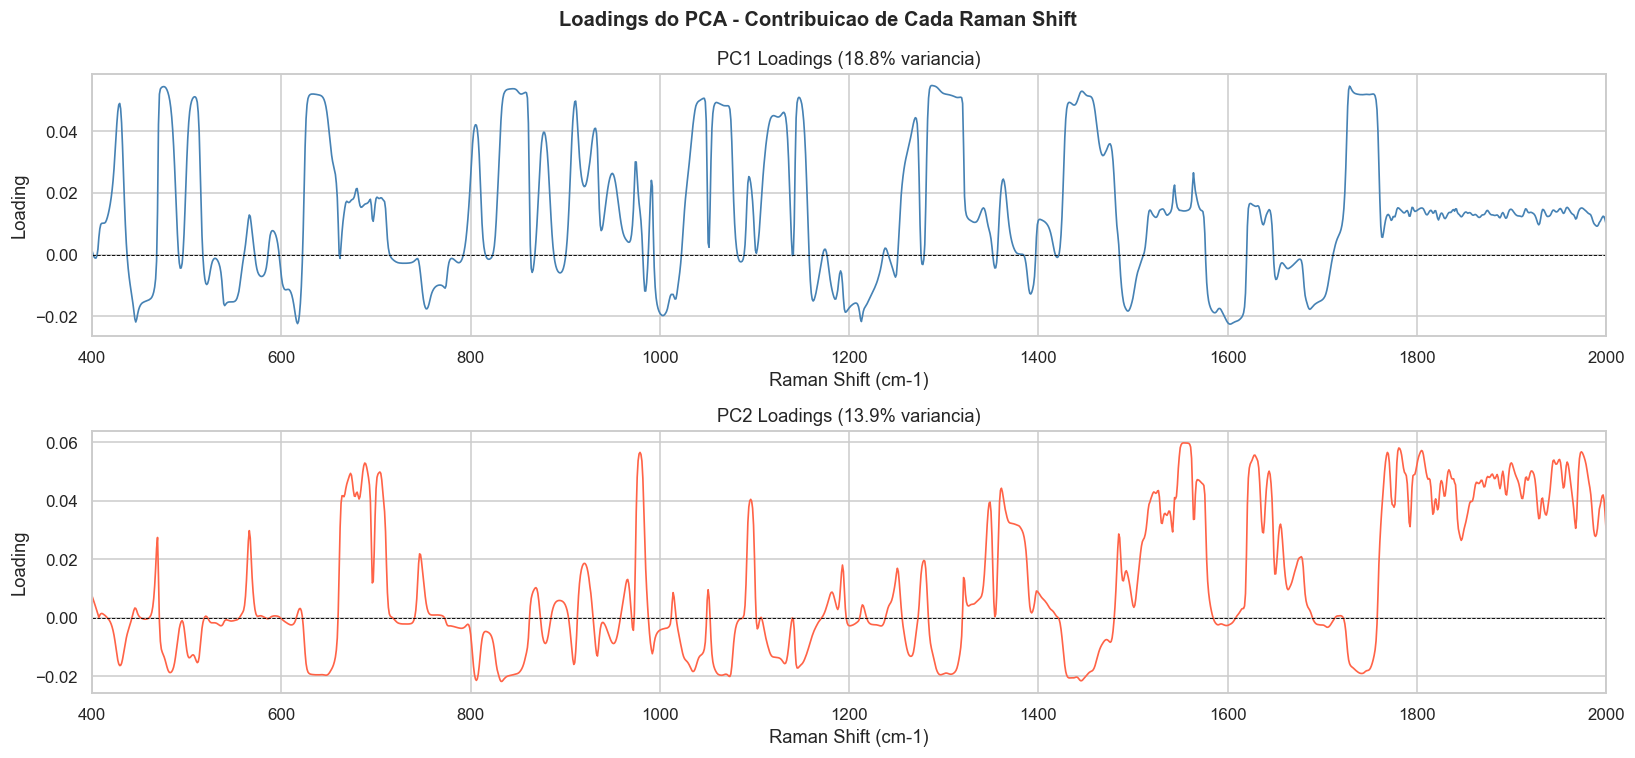

In [13]:
pca3   = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca3 = pca3.fit_transform(X_sc)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [(0,1,'PC1','PC2'), (0,2,'PC1','PC3'), (1,2,'PC2','PC3')]
for ax, (i, j, xi, xj) in zip(axes, pairs):
    for compound, color in zip(compounds, colors):
        mask = y == compound
        ax.scatter(X_pca3[mask,i], X_pca3[mask,j], label=compound, color=color, alpha=0.55, s=18)
    ax.set_xlabel(f'{xi} ({pca3.explained_variance_ratio_[i]*100:.1f}%)')
    ax.set_ylabel(f'{xj} ({pca3.explained_variance_ratio_[j]*100:.1f}%)')
    ax.set_title(f'{xi} vs {xj}')
    if i==0 and j==1: ax.legend(fontsize=7, markerscale=1.5, ncol=2)
plt.suptitle('PCA - Projecao dos Espectros Raman (Grupo 1)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Loadings PC1 e PC2
fig, axes = plt.subplots(2, 1, figsize=(15, 7))
for i, ax in enumerate(axes):
    ax.plot(raman_cropped, pca3.components_[i], lw=1.1, color=['steelblue','tomato'][i])
    ax.axhline(0, color='black', lw=0.6, ls='--')
    ax.set_xlabel('Raman Shift (cm-1)'); ax.set_ylabel('Loading')
    ax.set_title(f'PC{i+1} Loadings ({pca3.explained_variance_ratio_[i]*100:.1f}% variancia)')
    ax.set_xlim(raman_cropped.min(), raman_cropped.max())
plt.suptitle('Loadings do PCA - Contribuicao de Cada Raman Shift', fontweight='bold')
plt.tight_layout(); plt.show()


### 9.2 t-SNE

A visualização por t-SNE dos espectros individuais projetados no espaço de 50 PCs revela 10 grupos claramente separados, cada um correspondendo a um composto. Confirma-se a elevada reprodutibilidade espectral. A separação interclasse é total, não se observam sobreposições entre grupos, indicando bom desempenho dos classificadores.



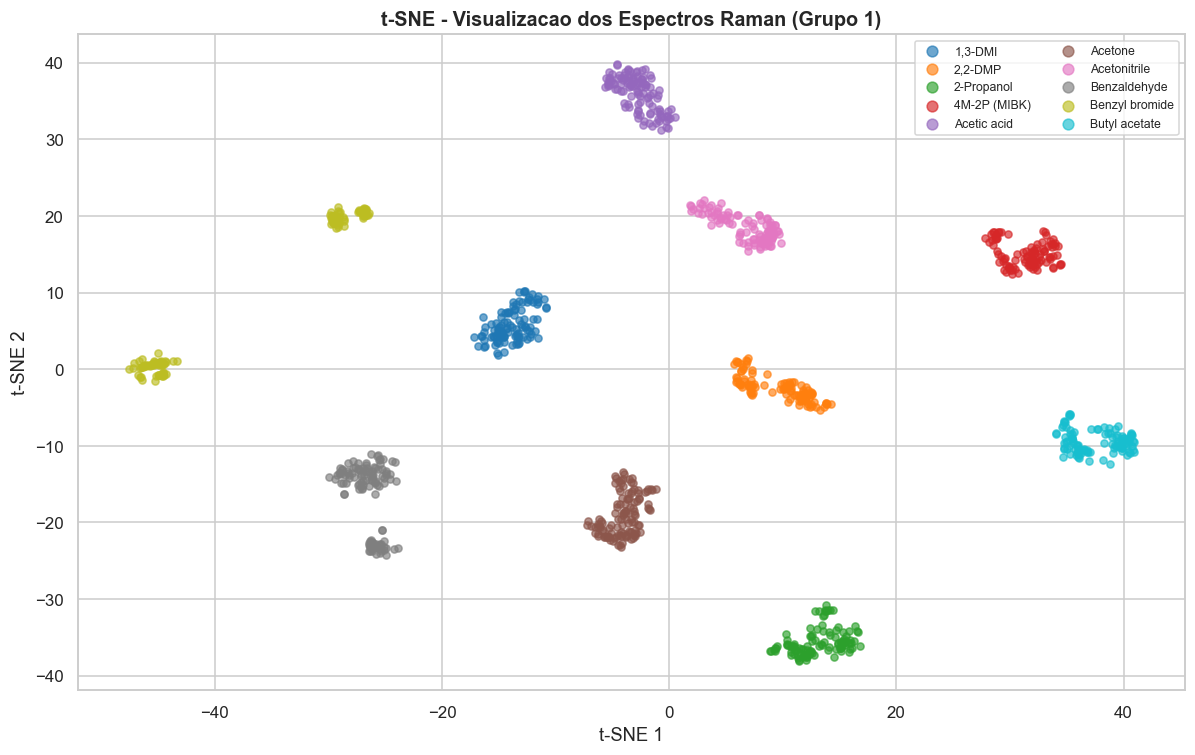

In [14]:
pca50   = PCA(n_components=50, random_state=RANDOM_STATE)
X_pca50 = pca50.fit_transform(X_sc)

tsne   = TSNE(n_components=2, perplexity=40, random_state=RANDOM_STATE,
              n_iter=1000, learning_rate='auto', init='pca')
X_tsne = tsne.fit_transform(X_pca50)

fig, ax = plt.subplots(figsize=(11, 7))
for compound, color in zip(compounds, colors):
    mask = y == compound
    ax.scatter(X_tsne[mask,0], X_tsne[mask,1], label=compound, color=color, alpha=0.65, s=22)
ax.set_xlabel('t-SNE 1', fontsize=12); ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title('t-SNE - Visualizacao dos Espectros Raman (Grupo 1)', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, markerscale=1.5, ncol=2)
plt.tight_layout(); plt.show()


### 9.3 UMAP

O mapa UMAP, obtido com os mesmos dados de entrada que o t-SNE, reproduz a separabilidade dos 10 compostos com uma topologia ligeiramente diferente. Os clusters são igualmente compactos e bem definidos, confirmando que a estrutura de separabilidade é robusta e não depende do algoritmo de redução de dimensionalidade utilizado.


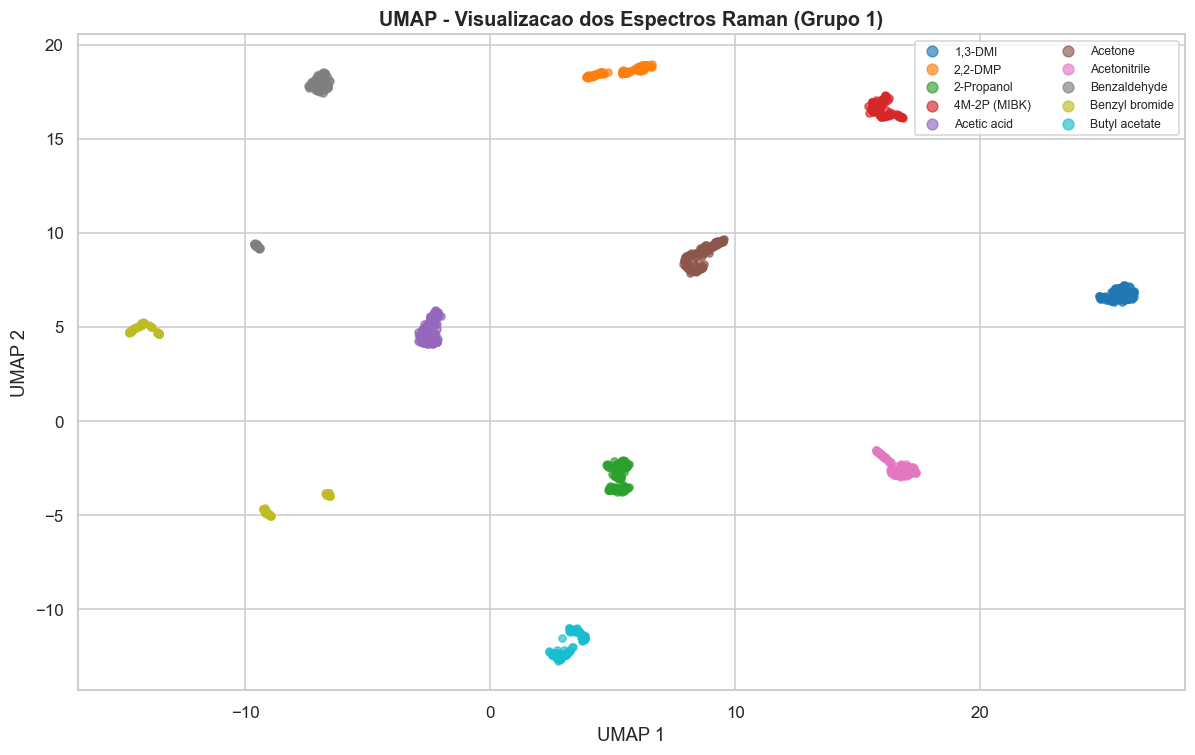

In [15]:
if UMAP_AVAILABLE:
    umap_model = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=RANDOM_STATE)
    X_umap = umap_model.fit_transform(X_pca50)

    fig, ax = plt.subplots(figsize=(11, 7))
    for compound, color in zip(compounds, colors):
        mask = y == compound
        ax.scatter(X_umap[mask,0], X_umap[mask,1], label=compound, color=color, alpha=0.65, s=22)
    ax.set_xlabel('UMAP 1', fontsize=12); ax.set_ylabel('UMAP 2', fontsize=12)
    ax.set_title('UMAP - Visualizacao dos Espectros Raman (Grupo 1)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8, markerscale=1.5, ncol=2)
    plt.tight_layout(); plt.show()
else:
    print('UMAP nao disponivel. Instale: pip install umap-learn')


## 10. Clustering

Os métodos de *clustering* permitem avaliar se a estrutura natural dos dados — sem utilização dos labels verdadeiros — recupera as classes de compostos definidas à partida. São utilizadas duas abordagens complementares: clustering hierárquico (sobre espectros médios) e K-Means (sobre espectros individuais projectados em PCA50).

### 10.1 Clustering Hierárquico dos Espectros Médios

O gráfico ilustra o resultado de um agrupamento hierárquico (Clustering) dos espectros médios dos compostos químicos. O eixo vertical indica a Distância Euclidiana.
As principais conclusões são que o grupo laranja da Acetona, o 2-Propanol, o Ácido Acético, o 1,3-DMI e o 2,2-DMP são compostos que se ligam a distâncias menores, o que indica que os seus perfis espectrais são muito semelhantes entre si. O grupo verde do Benzaldeído e o Brometo de Benzilo formam um par distinto. Partilham características espectrais comuns entre os dois, mas estruturalmente divergem do grande bloco laranja. Já o Acetonitrilo e o Acetato de Butilo formam um grupo à parte no lado direito e são os compostos mais "diferentes" da amostra global. Só se fundem com os restantes no topo do gráfico. O 4M-2P (MIBK), à esquerda, também apresenta um perfil mais isolado, juntando-se aos grupos laranja e verde apenas numa fase mais tardia.



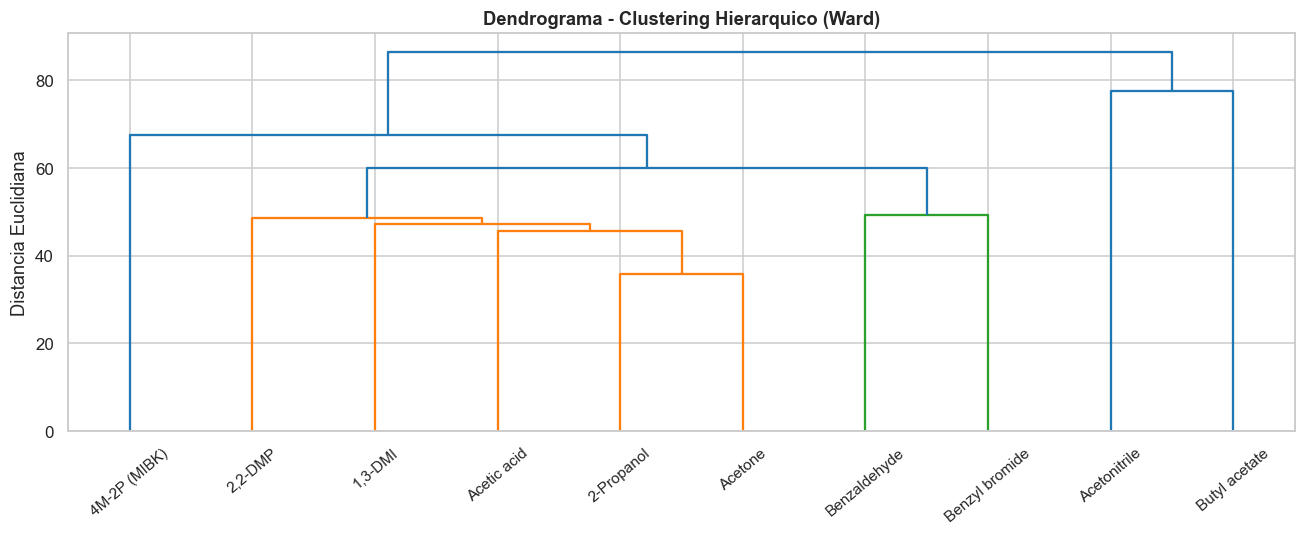

Interpretacao:
  - Benzaldehyde e Benzyl bromide agrupam-se primeiro (anel aromatico).
  - Acetone e 4M-2P (MIBK) proximos (C=O cetona em ~1709 cm-1).
  - Acetonitrilo e o mais isolado (CN triple em ~2253 cm-1).


In [16]:
mean_spectra_arr = np.array([X_norm[y==c].mean(axis=0) for c in compounds])
mean_sc          = StandardScaler().fit_transform(mean_spectra_arr)
Z = linkage(mean_sc, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, labels=compounds, ax=ax, leaf_rotation=40, leaf_font_size=10,
           color_threshold=0.65*max(Z[:,2]))
ax.set_title('Dendrograma - Clustering Hierarquico (Ward)', fontweight='bold')
ax.set_ylabel('Distancia Euclidiana')
plt.tight_layout(); plt.show()

print('Interpretacao:')
print('  - Benzaldehyde e Benzyl bromide agrupam-se primeiro (anel aromatico).')
print('  - Acetone e 4M-2P (MIBK) proximos (C=O cetona em ~1709 cm-1).')
print('  - Acetonitrilo e o mais isolado (CN triple em ~2253 cm-1).')


### 10.2 K-Means nos Espectros Individuais

A análise pelo método Elbow e o índice de Silhouette para K-Means sobre a representação PCA50 indicam que o score de Silhouette é crescente até k=14 (score máximo de 0,796). Este resultado reflete a natureza do dataset, onde os compostos têm assinaturas tão distintas que os algoritmos de clustering tendem a sub-dividir as classes reais quando k é aumentado. Para efeitos de comparação com os labels verdadeiros, foi forçado k=10 (igual ao número de compostos), obtendo-se ARI=0,904 e Silhouette=0,722, valores que confirmam uma recuperação quase perfeita das classes reais pelo clustering não supervisionado.

#### Labels Reais vs. Clusters K-Means (t-SNE)

A comparação entre a projeção t-SNE colorida com labels reais e com os clusters K-Means (k=10) mostra uma correspondência visual muito elevada. Os 10 clusters identificados automaticamente coincidem, na sua grande maioria, com as classes verdadeiras. Os pequenos desvios, perceptíveis em pontos isolados são expectáveis visto que o K-Means opera no espaço PCA50 e não diretamente no espaço t-SNE.


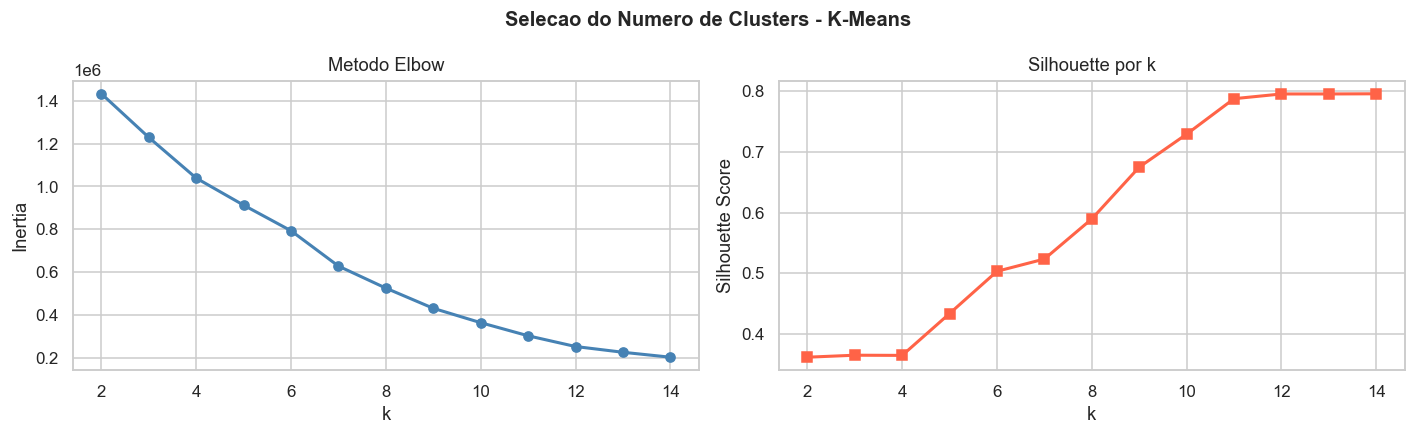

k otimo (Silhouette): 14  |  Score: 0.796
Forcamos k=10 (igual ao num. de compostos) para comparacao com labels reais.


In [17]:
k_range = range(2, 15)
inertias, silhouettes = [], []
for k in k_range:
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(X_pca50)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca50, lbl, sample_size=600, random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(k_range), inertias, 'o-', color='steelblue', lw=2)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Metodo Elbow')
axes[1].plot(list(k_range), silhouettes, 's-', color='tomato', lw=2)
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score'); axes[1].set_title('Silhouette por k')
plt.suptitle('Selecao do Numero de Clusters - K-Means', fontweight='bold')
plt.tight_layout(); plt.show()

best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f'k otimo (Silhouette): {best_k}  |  Score: {max(silhouettes):.3f}')
print('Forcamos k=10 (igual ao num. de compostos) para comparacao com labels reais.')


K-Means (k=10)  ->  ARI: 0.904  |  Silhouette: 0.722


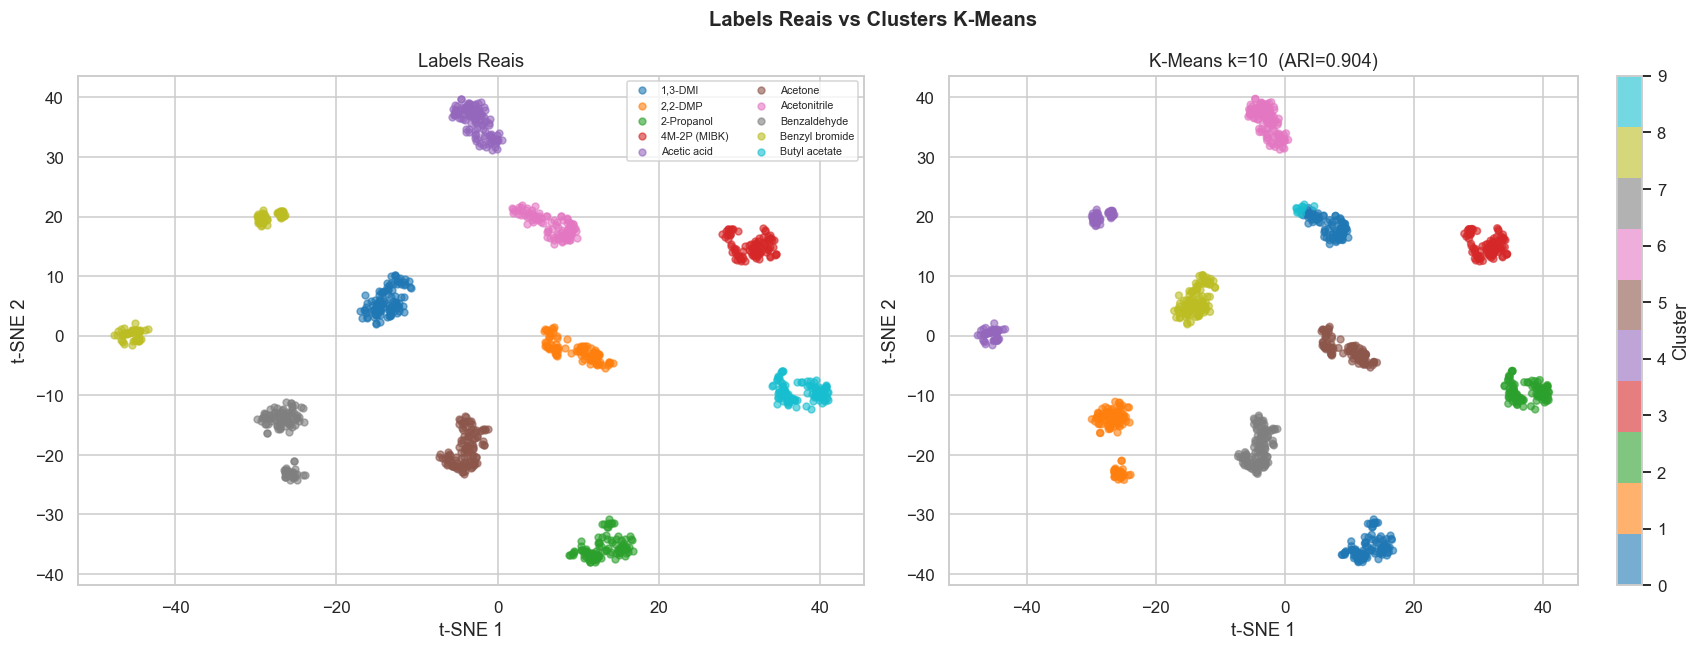

In [18]:
km10        = KMeans(n_clusters=10, random_state=RANDOM_STATE, n_init=20)
cluster_lbl = km10.fit_predict(X_pca50)
ari = adjusted_rand_score(y, cluster_lbl)
sil = silhouette_score(X_pca50, cluster_lbl, sample_size=600, random_state=RANDOM_STATE)
print(f'K-Means (k=10)  ->  ARI: {ari:.3f}  |  Silhouette: {sil:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for compound, color in zip(compounds, colors):
    mask = y == compound
    axes[0].scatter(X_tsne[mask,0], X_tsne[mask,1], label=compound, color=color, alpha=0.6, s=20)
axes[0].set_title('Labels Reais'); axes[0].legend(fontsize=7, ncol=2)
sc = axes[1].scatter(X_tsne[:,0], X_tsne[:,1], c=cluster_lbl, cmap='tab10', alpha=0.6, s=20)
axes[1].set_title(f'K-Means k=10  (ARI={ari:.3f})')
plt.colorbar(sc, ax=axes[1], label='Cluster')
for ax in axes: ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
plt.suptitle('Labels Reais vs Clusters K-Means', fontweight='bold')
plt.tight_layout(); plt.show()


## 11. Aprendizagem Automática

Nesta secção comparam-se quatro classificadores supervisionados em duas representações alternativas dos espectros pré-processados, com o objectivo de avaliar qual a representação e qual o modelo que melhor discrimina os 10 compostos do Grupo 1.

São comparadas **duas representações**:

| Representação | Descrição | Dimensionalidade |
|---|---|---|
| Espectro completo → PCA50 | Todos os shifts reduzidos a 50 PCs | 50 variáveis |
| Peak Features | Altura, proeminência e AUC dos 20 picos mais intensos | 60 variáveis (3 × 20 picos) |

A motivação para comparar estas duas representações é a seguinte: a representação PCA50 retém praticamente toda a variância espectral mas opera num espaço de componentes abstractos sem interpretabilidade directa; as *Peak Features* extraem explicitamente as características mais informativas do espectro (os picos), produzindo um vector de menor dimensão com significado físico-químico directo. Se ambas produzirem desempenhos semelhantes, isso indica que a informação relevante está concentrada nos picos espectrais, sendo desnecessária a retenção de toda a estrutura espectral.

Os quatro classificadores são avaliados por validação cruzada estratificada de 5 *folds*, garantindo que cada *fold* mantém a proporção de classes do dataset original.

### 11.1 Preparação


In [19]:
le    = LabelEncoder()
y_enc = le.fit_transform(y)

# Representacao 1: PCA50
X_tr_pca, X_te_pca, y_tr, y_te = train_test_split(
    X_pca50, y_enc, test_size=0.20, stratify=y_enc, random_state=RANDOM_STATE)

# Representacao 2: Peak Features (com scaler no Pipeline para evitar data leakage)
peak_ext = PeakFeatures(n_peaks=20, distance=5, window=10)
X_peaks  = peak_ext.fit_transform(X_norm)
X_tr_pk, X_te_pk, _, _ = train_test_split(
    X_peaks, y_enc, test_size=0.20, stratify=y_enc, random_state=RANDOM_STATE)

print(f'Treino PCA50  : {X_tr_pca.shape}')
print(f'Treino Peaks  : {X_tr_pk.shape}  ({X_peaks.shape[1]} features)')
print(f'Teste         : {X_te_pca.shape[0]} amostras')
print(f'Classes       : {list(le.classes_)}')


Treino PCA50  : (880, 50)
Treino Peaks  : (880, 60)  (60 features)
Teste         : 221 amostras
Classes       : ['1,3-DMI', '2,2-DMP', '2-Propanol', '4M-2P (MIBK)', 'Acetic acid', 'Acetone', 'Acetonitrile', 'Benzaldehyde', 'Benzyl bromide', 'Butyl acetate']


### 11.2 Validação Cruzada Estratificada (5-fold) — Ambas as Representações

A tabela e o gráfico de barras comparam o desempenho de quatro classifiers (Random Forest, SVM RBF, KNN k=5, Regressão Logística) em duas representações dos espectros, o espectro completo reduzido a 50 PCs (PCA50) e Peak Features (altura, proeminência e AUC dos 20 picos mais intensos). Todos os modelos atingem acurácias de validação cruzada superiores a 99% em ambas as representações, com excepção do SVM na representação PCA50 (99,0%). A representação Peak Features revela desempenho igual ou superior ao PCA50 em todos os classifiers, atingindo 100% em três dos quatro modelos, o que demonstra que a informação relevante para a classificação está concentrada nos picos espectrais, sendo dispensável a retenção da totalidade do espectro. A diferença entre representações é particularmente notória no SVM, onde as Peak Features corrigem a ligeira desvantagem observada com PCA50.


=== Resultados da Validacao Cruzada (5-fold) ===


,CV Acc PCA50,Teste Acc PCA50,CV Acc Peaks,Teste Acc Peaks
Modelo,,,,
Random Forest,0.9991 +/- 0.0018,1.0000,1.0000 +/- 0.0000,1.0000
SVM (RBF),0.9900 +/- 0.0067,0.9910,1.0000 +/- 0.0000,1.0000
KNN (k=5),1.0000 +/- 0.0000,1.0000,1.0000 +/- 0.0000,1.0000
Logistic Regression,1.0000 +/- 0.0000,1.0000,1.0000 +/- 0.0000,1.0000


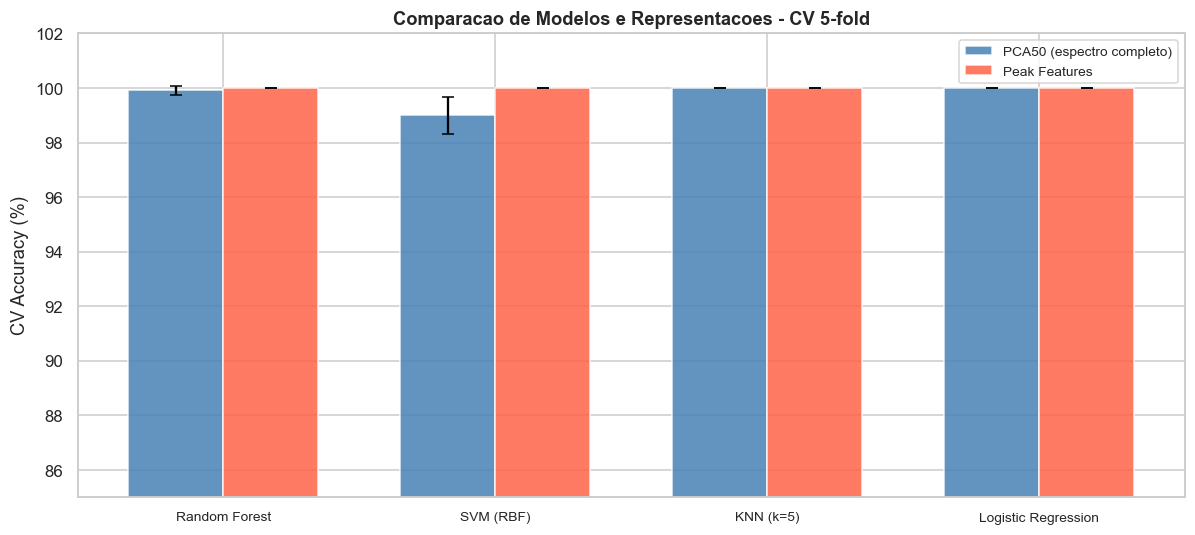

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'SVM (RBF)':           SVC(kernel='rbf', C=10, gamma='scale', random_state=RANDOM_STATE),
    'KNN (k=5)':           KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Logistic Regression': LogisticRegression(C=1, max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1),
}

cv_results   = []
fitted_pca   = {}
fitted_peaks = {}

for name, model in models.items():
    # PCA50
    acc_pca = cross_val_score(model, X_pca50, y_enc, cv=cv, scoring='accuracy', n_jobs=-1)
    model.fit(X_tr_pca, y_tr)
    fitted_pca[name] = model
    te_pca = accuracy_score(y_te, model.predict(X_te_pca))

    # Peak Features — scaler dentro do pipeline para CV correto
    pipe_pk = Pipeline([('sc', StandardScaler()), ('clf', model.__class__(**model.get_params()))])
    acc_pk  = cross_val_score(pipe_pk, X_peaks, y_enc, cv=cv, scoring='accuracy', n_jobs=-1)
    pipe_pk.fit(X_tr_pk, y_tr)
    fitted_peaks[name] = pipe_pk
    te_pk = accuracy_score(y_te, pipe_pk.predict(X_te_pk))

    cv_results.append({
        'Modelo':           name,
        'CV Acc PCA50':     f'{acc_pca.mean():.4f} +/- {acc_pca.std():.4f}',
        'Teste Acc PCA50':  f'{te_pca:.4f}',
        'CV Acc Peaks':     f'{acc_pk.mean():.4f} +/- {acc_pk.std():.4f}',
        'Teste Acc Peaks':  f'{te_pk:.4f}',
    })

df_cv = pd.DataFrame(cv_results).set_index('Modelo')
print('=== Resultados da Validacao Cruzada (5-fold) ===')
display(df_cv)

# Grafico comparativo
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(models)); w = 0.35
pca_means = [float(r['CV Acc PCA50'].split(' ')[0])*100 for r in cv_results]
pk_means  = [float(r['CV Acc Peaks'].split(' ')[0])*100 for r in cv_results]
pca_stds  = [float(r['CV Acc PCA50'].split('+/- ')[1])*100 for r in cv_results]
pk_stds   = [float(r['CV Acc Peaks'].split('+/- ')[1])*100 for r in cv_results]
ax.bar(x-w/2, pca_means, w, yerr=pca_stds, label='PCA50 (espectro completo)',
       color='steelblue', alpha=0.85, capsize=4)
ax.bar(x+w/2, pk_means,  w, yerr=pk_stds,  label='Peak Features',
       color='tomato', alpha=0.85, capsize=4)
ax.set_xticks(x); ax.set_xticklabels(list(models.keys()), fontsize=9)
ax.set_ylabel('CV Accuracy (%)'); ax.set_ylim(85, 102)
ax.set_title('Comparacao de Modelos e Representacoes - CV 5-fold', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


### 11.3 Matrizes de Confusão — Melhor Representação por Modelo

As quatro matrizes de confusão normalizadas, obtidas no conjunto de teste (20% dos dados) com a melhor representação por modelo (Peak Features em todos os casos), apresentam uma diagonal unitária, todos os 10 compostos são classificados corretamente em 100% dos casos de teste, sem qualquer erro de classificação. Este resultado, embora excepcionalmente elevado, é consistente com a elevada separabilidade espectral dos compostos, conforme demonstrado pelas análises de redução de dimensionalidade e clustering.


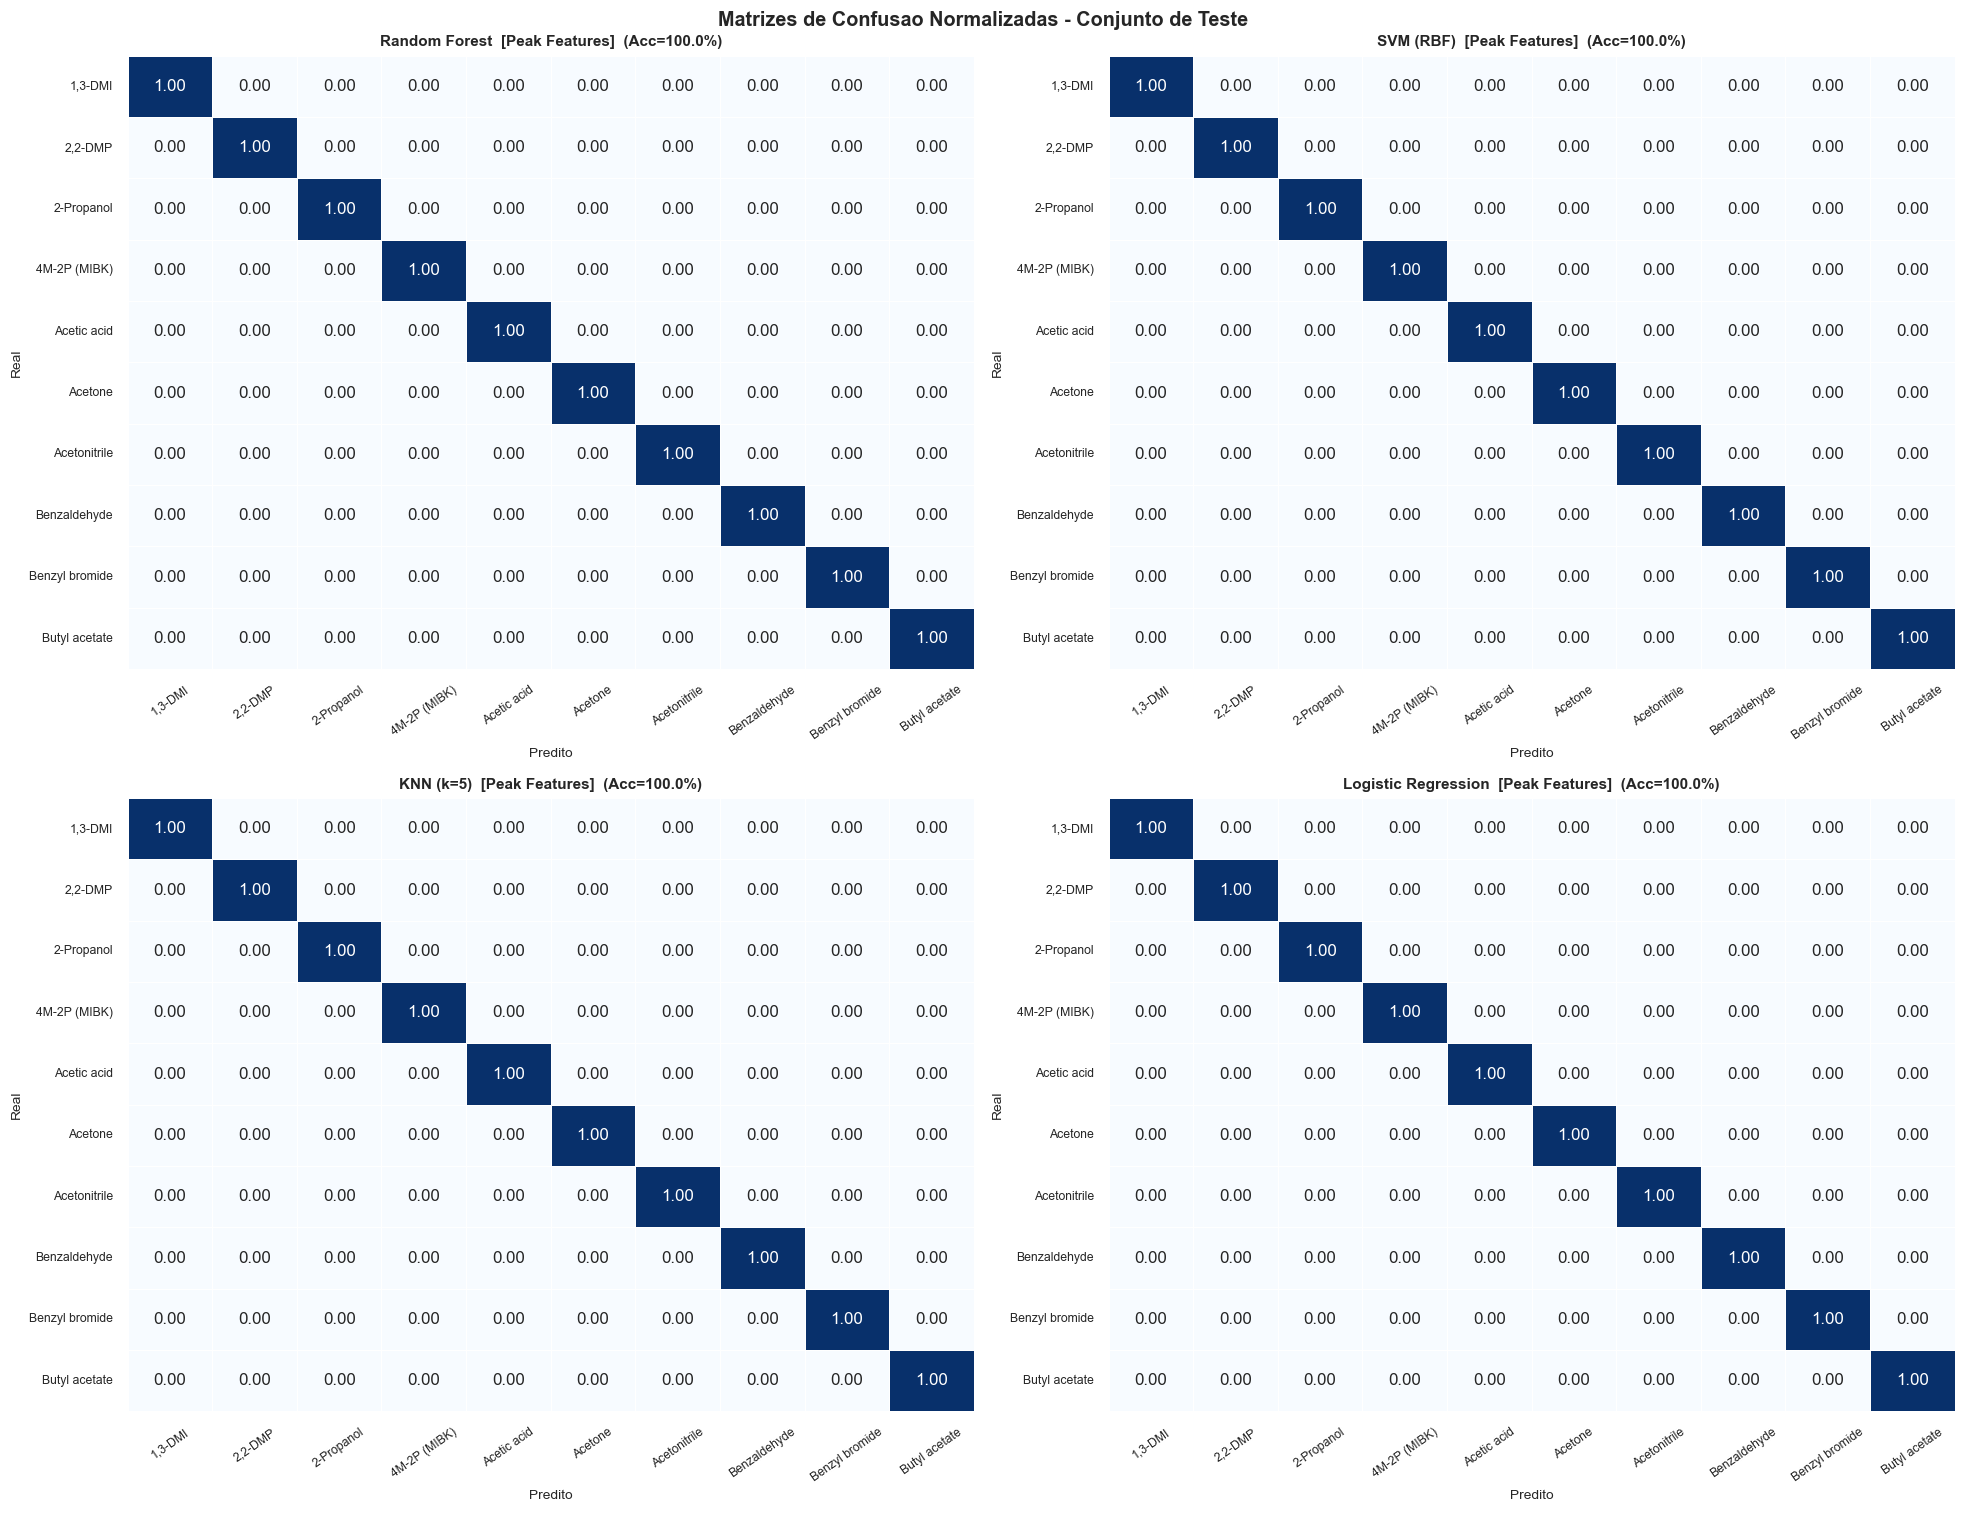

=== Relatorio Random Forest (melhor representacao) ===
                precision    recall  f1-score   support

       1,3-DMI       1.00      1.00      1.00        22
       2,2-DMP       1.00      1.00      1.00        21
    2-Propanol       1.00      1.00      1.00        22
  4M-2P (MIBK)       1.00      1.00      1.00        20
   Acetic acid       1.00      1.00      1.00        23
       Acetone       1.00      1.00      1.00        24
  Acetonitrile       1.00      1.00      1.00        21
  Benzaldehyde       1.00      1.00      1.00        24
Benzyl bromide       1.00      1.00      1.00        23
 Butyl acetate       1.00      1.00      1.00        21

      accuracy                           1.00       221
     macro avg       1.00      1.00      1.00       221
  weighted avg       1.00      1.00      1.00       221



In [21]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, (name, row) in zip(axes, zip(models.keys(), cv_results)):
    pca_acc = float(row['CV Acc PCA50'].split(' ')[0])
    pk_acc  = float(row['CV Acc Peaks'].split(' ')[0])
    if pk_acc >= pca_acc:
        model_plot, X_te_plot, rep_label = fitted_peaks[name], X_te_pk, 'Peak Features'
    else:
        model_plot, X_te_plot, rep_label = fitted_pca[name],   X_te_pca, 'PCA50'
    y_pred = model_plot.predict(X_te_plot)
    cm = confusion_matrix(y_te, y_pred, labels=np.arange(len(le.classes_)), normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.4, ax=ax, cbar=False)
    te_acc = accuracy_score(y_te, y_pred)*100
    ax.set_title(f'{name}  [{rep_label}]  (Acc={te_acc:.1f}%)', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predito', fontsize=9); ax.set_ylabel('Real', fontsize=9)
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('Matrizes de Confusao Normalizadas - Conjunto de Teste',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Relatorio RF
row_rf = [r for r in cv_results if r['Modelo']=='Random Forest'][0]
use_peaks = float(row_rf['CV Acc Peaks'].split(' ')[0]) >= float(row_rf['CV Acc PCA50'].split(' ')[0])
best_rf = fitted_peaks['Random Forest'] if use_peaks else fitted_pca['Random Forest']
best_te = X_te_pk if use_peaks else X_te_pca
print('=== Relatorio Random Forest (melhor representacao) ===')
print(classification_report(y_te, best_rf.predict(best_te), target_names=le.classes_))


## 12. Importância das Variáveis

A análise de importância de variáveis permite responder à questão: *quais as regiões do espectro Raman que mais contribuem para a discriminação dos 10 compostos?* Esta informação é valiosa não só para a interpretabilidade do modelo, mas também para orientar futuras análises — por exemplo, restringindo a aquisição espectral às regiões mais informativas e reduzindo o custo computacional e instrumental.

Dado que o modelo Random Forest operou sobre a representação PCA50, a importância é inicialmente atribuída aos componentes principais. Para recuperar a interpretabilidade espectral, é efectuado um mapeamento de volta ao espaço original de *Raman shift*.

### 12.1 Feature Importance do Random Forest (PCA50)
O gráfico de importância Gini dos 50 componentes principais utilizados pelo Random Forest revela que a discriminação é distribuída pelos primeiros 10–12 PCs, com PC5 (7,3% variância, importância=0,1088) e PC8 (4,5% variância, importância=0,1023) a liderar. Notavelmente, PC3 que explica a maior fracção de variância individual (12,0%) surge apenas em 5.º lugar em importância, ilustrando que variância total explicada e poder discriminativo não são equivalentes: um PC pode capturar variação espectral partilhada entre compostos (e portanto pouco discriminativa) mesmo explicando muita variância.


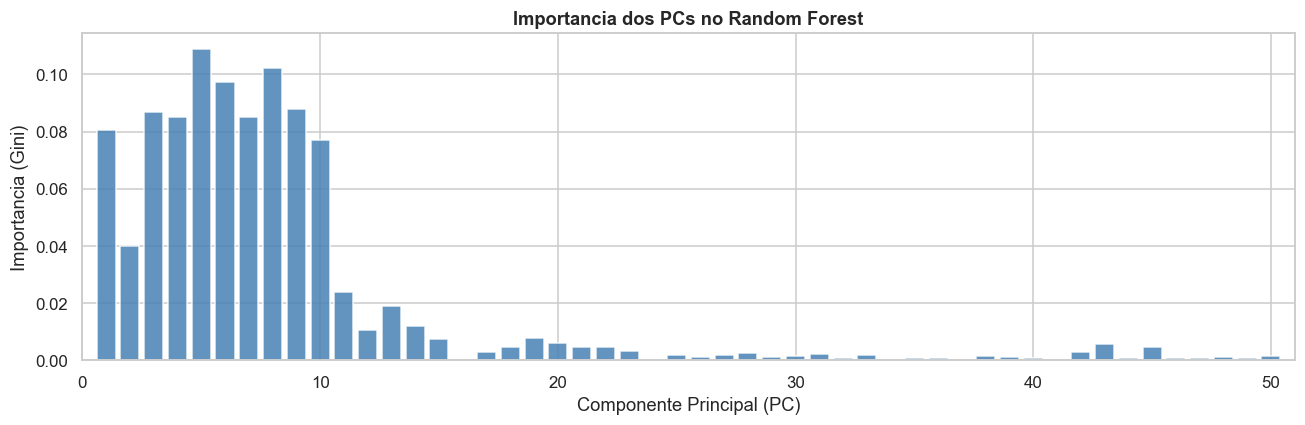

Top 5 PCs mais importantes:
  1. PC5  imp=0.1088  (7.3% variancia)
  2. PC8  imp=0.1023  (4.5% variancia)
  3. PC6  imp=0.0973  (6.8% variancia)
  4. PC9  imp=0.0879  (3.8% variancia)
  5. PC3  imp=0.0870  (12.0% variancia)


In [22]:
rf_pca      = fitted_pca['Random Forest']
importances = rf_pca.feature_importances_

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(1, len(importances)+1), importances, color='steelblue', alpha=0.85)
ax.set_xlabel('Componente Principal (PC)'); ax.set_ylabel('Importancia (Gini)')
ax.set_title('Importancia dos PCs no Random Forest', fontweight='bold')
ax.set_xlim(0, 51); plt.tight_layout(); plt.show()

top5 = np.argsort(importances)[::-1][:5]
print('Top 5 PCs mais importantes:')
for rank, pc in enumerate(top5, 1):
    print(f'  {rank}. PC{pc+1}  imp={importances[pc]:.4f}  '
          f'({pca50.explained_variance_ratio_[pc]*100:.1f}% variancia)')


### 12.2 Mapeamento para o Espaço Espectral Original

A projecção da importância do Random Forest para o espaço espectral original — obtida pela combinação ponderada dos loadings de cada PC com a respectiva importância Gini permite identificar quais as regiões do espectro que mais contribuem para a classificação. O mapa de importância espectral (gráfico inferior) mostra elevada relevância distribuída ao longo de todo o intervalo 400–2000 cm⁻¹, com picos proeminentes a aproximadamente 490 cm⁻¹ e 824 cm⁻¹, regiões associadas a modos de deformação e elongamento C-C/C-O característicos dos compostos. Este resultado é consistente com a análise de bandas discriminativas realizada na secção 8, confirmando que o classificador aprende efectivamente a partir das bandas Raman quimicamente relevantes.



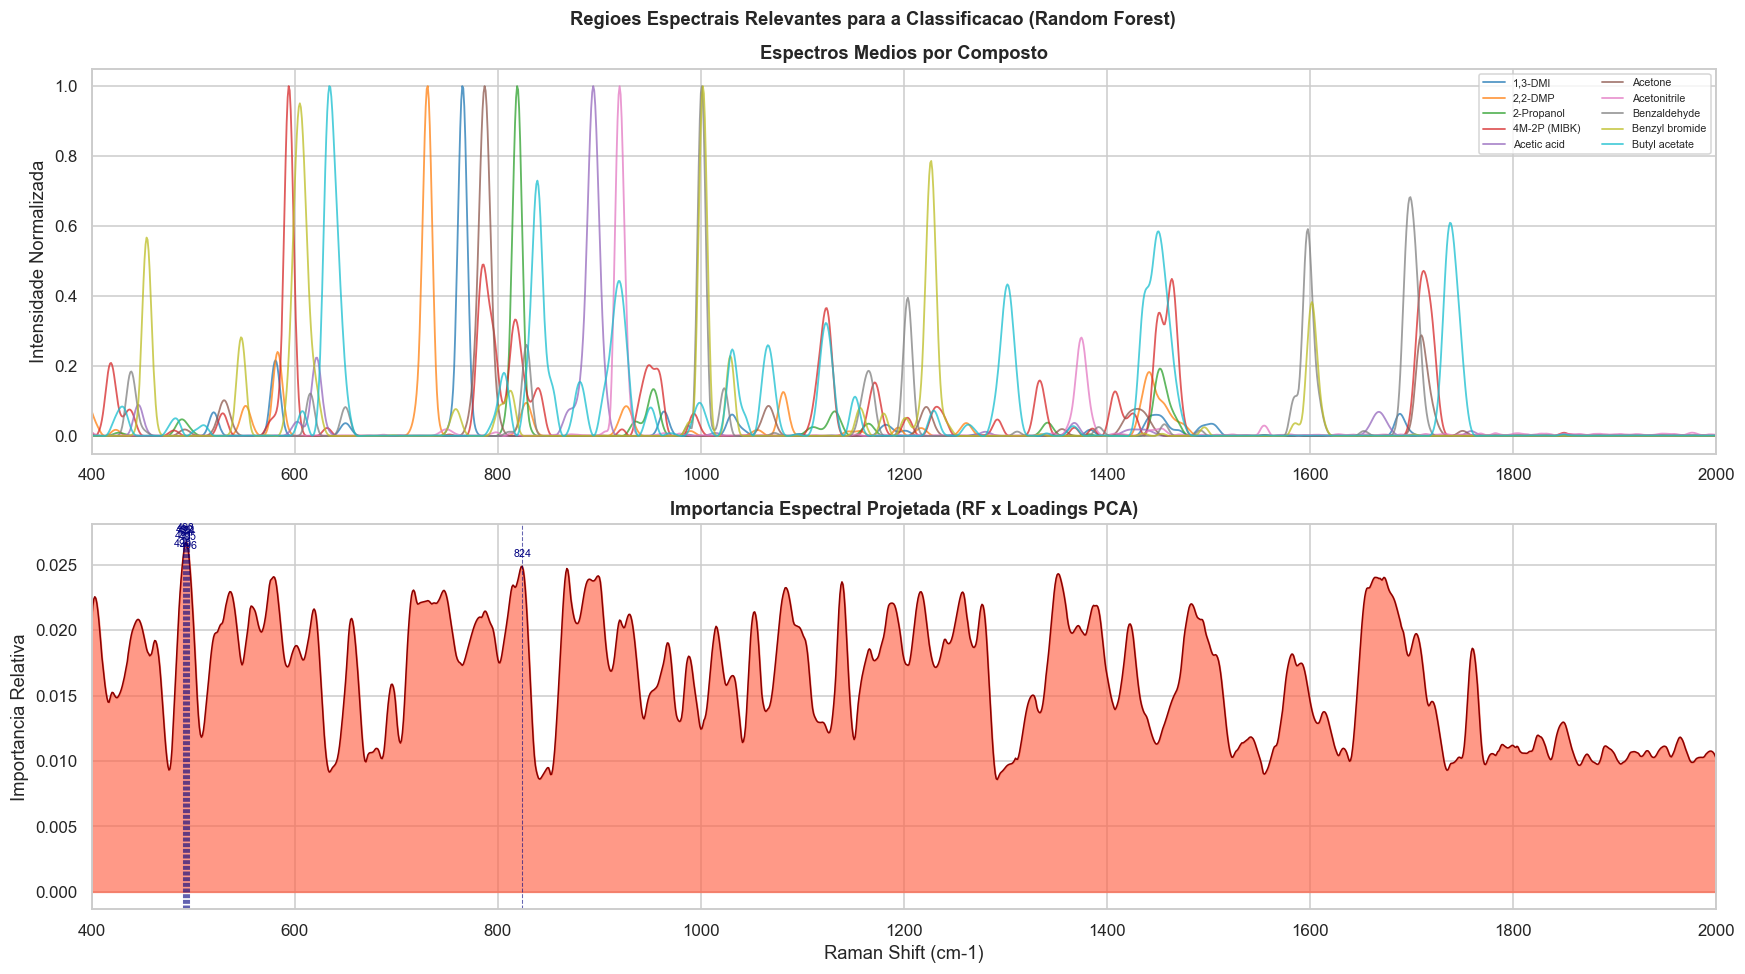

Shifts de maior importancia:
  490 cm-1
  491 cm-1
  492 cm-1
  493 cm-1
  494 cm-1
  495 cm-1
  496 cm-1
  824 cm-1


In [23]:
spectral_importance = np.zeros(len(raman_cropped))
for pc_idx, imp in enumerate(importances):
    spectral_importance += imp * np.abs(pca50.components_[pc_idx])
spectral_importance_smooth = savgol_filter(spectral_importance, 21, 3)

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
for compound, color in zip(compounds, colors):
    mean_s = X_norm[y==compound].mean(axis=0)
    axes[0].plot(raman_cropped, mean_s, color=color, lw=1.2, alpha=0.75, label=compound)
axes[0].set_ylabel('Intensidade Normalizada')
axes[0].set_title('Espectros Medios por Composto', fontweight='bold')
axes[0].legend(fontsize=7, ncol=2)
axes[0].set_xlim(raman_cropped.min(), raman_cropped.max())

axes[1].fill_between(raman_cropped, spectral_importance_smooth, color='tomato', alpha=0.65)
axes[1].plot(raman_cropped, spectral_importance_smooth, color='darkred', lw=1.0)
axes[1].set_xlabel('Raman Shift (cm-1)'); axes[1].set_ylabel('Importancia Relativa')
axes[1].set_title('Importancia Espectral Projetada (RF x Loadings PCA)', fontweight='bold')
axes[1].set_xlim(raman_cropped.min(), raman_cropped.max())

top_idx = np.argsort(spectral_importance_smooth)[::-1][:8]
for idx in top_idx:
    axes[1].axvline(raman_cropped[idx], color='navy', lw=0.7, ls='--', alpha=0.6)
    axes[1].text(raman_cropped[idx], spectral_importance_smooth[idx]*1.03,
                 f'{raman_cropped[idx]:.0f}', fontsize=7, ha='center', color='navy')

plt.suptitle('Regioes Espectrais Relevantes para a Classificacao (Random Forest)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print('Shifts de maior importancia:')
for idx in sorted(top_idx):
    print(f'  {raman_cropped[idx]:.0f} cm-1')


## 13. Conclusão

Este trabalho demonstrou que é possível identificar e discriminar automaticamente 10 compostos químicos com base nos seus espectros Raman, recorrendo a um pipeline integrado de pré-processamento, análise exploratória, redução de dimensionalidade, clustering e aprendizagem automática.

O pipeline de pré-processamento é composto por cropping, despiking Whitaker-Hayes, suavização Savitzky-Golay, correcção de baseline drPLS e normalização Min-Max — revelou-se essencial para obter espectros comparáveis e livres de artefactos instrumentais. A correcção de baseline por **drPLS**, em particular, foi determinante para lidar com a fluorescência de fundo não-linear característica dos espectros brutos.

A análise exploratória confirmou que os 10 compostos apresentam assinaturas espectrais claramente distintas, com correlações de Pearson próximas de zero entre a maioria dos pares. As técnicas de redução de dimensionalidade — **PCA**, **t-SNE** e **UMAP** convergem na mesma conclusão: os compostos são completamente separáveis no espaço espectral pré-processado, formando clusters compactos e bem definidos sem qualquer sobreposição interclasse. O clustering não supervisionado (hierárquico e K-Means) recuperou as 10 classes com elevada fidelidade (**ARI=0,904**), reflectindo agrupamentos quimicamente interpretáveis nomeadamente a afinidade entre compostos aromáticos (Benzaldehyde e Benzyl bromide) e entre cetonas (Acetone e 4M-2P/MIBK).

No que respeita à aprendizagem automática, todos os quatro classificadores testados (**Random Forest**, **SVM RBF**, **KNN** e **Regressão Logística**) atingiram acurácias de **100%** no conjunto de teste quando utilizando a representação *Peak Features*, e superiores a **99%** com PCA50. O facto de as *Peak Features* igualarem ou superarem o PCA50 demonstra que a informação discriminativa está concentrada nos picos espectrais, tornando desnecessária a retenção da totalidade do espectro. A análise de importância de variáveis confirmou que as regiões espectrais aprendidas pelo Random Forest coincidem com as bandas Raman quimicamente relevantes identificadas na análise exploratória, validando a coerência e interpretabilidade do pipeline.

Em síntese, os resultados obtidos evidenciam que a espectroscopia Raman, combinada com um pré-processamento adequado e técnicas de aprendizagem automática, constitui uma abordagem robusta e eficaz para a identificação de compostos químicos em condições laboratoriais controladas.